<a href="https://colab.research.google.com/github/Ali-al-hanafi/Basic-AI-EDA-Visualizations/blob/main/AI_Tasks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
print("Hello Ali!")

Hello Ali!


## **INSTALLING OPENAI**

In [ ]:
pip install openai

# **Using OpenAI Response API in Code**

In [ ]:
from google.colab import userdata
import base64
from IPython.display import Image,display
from openai import OpenAI
api_key = userdata.get("OpenAIKey")
client = OpenAI(api_key = api_key)

def ask(prompt):
  response = client.responses.create(
      model = 'gpt-5',
      input = prompt,
      max_output_tokens=20
  )
  return response.output_text
print(ask("Who is founder of Pakistan?"))

RateLimitError: Error code: 429 - {'error': {'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, read the docs: https://platform.openai.com/docs/guides/error-codes/api-errors.', 'type': 'insufficient_quota', 'param': None, 'code': 'insufficient_quota'}}

## **Image Generation**

In [ ]:
def generate_image(prompt):
  response = client.images.generate(
      model = 'gpt-image-1',
      prompt = prompt,
      size="1024x1024",
      n = 1
  )
  image_bytes = base64.b64decode(result.data[0].b64_json)
  display(Image(data = image_bytes))
generate_image("Imagine an ocean")

BadRequestError: Error code: 400 - {'error': {'message': 'Billing hard limit has been reached.', 'type': 'billing_limit_user_error', 'param': None, 'code': 'billing_hard_limit_reached'}}

# **Pandas**

In [ ]:
import pandas as pd

file = pd.read_csv("/content/ai_student_impact_dataset (1).csv")
#file[file['Student_ID'] == 100001]
#file.describe()
#file.shape
#file.dtypes
#print(file.head())

,Student_ID,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Burnout_Risk_Level
0,100001,Humanities,Senior,2.418,23.31,Copywriting/Drafting,Beginner,1,True,8.13,5,Allowed_With_Citation,6,2.393,86.44,High


# **Pandas, NumPy and Plot**

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
sns.set(color_codes = True)

df = pd.read_csv("/content/ai_student_impact_dataset (1).csv")
df.dtypes
df.tail()
df = df.drop(['Year_of_Study'], axis=1)
df = df.rename(columns ={"Major_Category":"Category"})
duplicate_rows = df[df.duplicated()]
print(duplicate_rows.shape)
df.count()
df = df.drop_duplicates()
df.isnull().sum()
df.dropna(inplace=True)
sns.boxplot(x = df['Post_Semester_GPA'])
df = df.select_dtypes(include = ['int64','float64'])
Q1 = df.quantile(0.25,numeric_only=True)
Q3 = df.quantile(0.75,numeric_only=True)
IQR = Q3-Q1
print(IQR)
df.corr(numeric_only=True)


# **Seaborn**

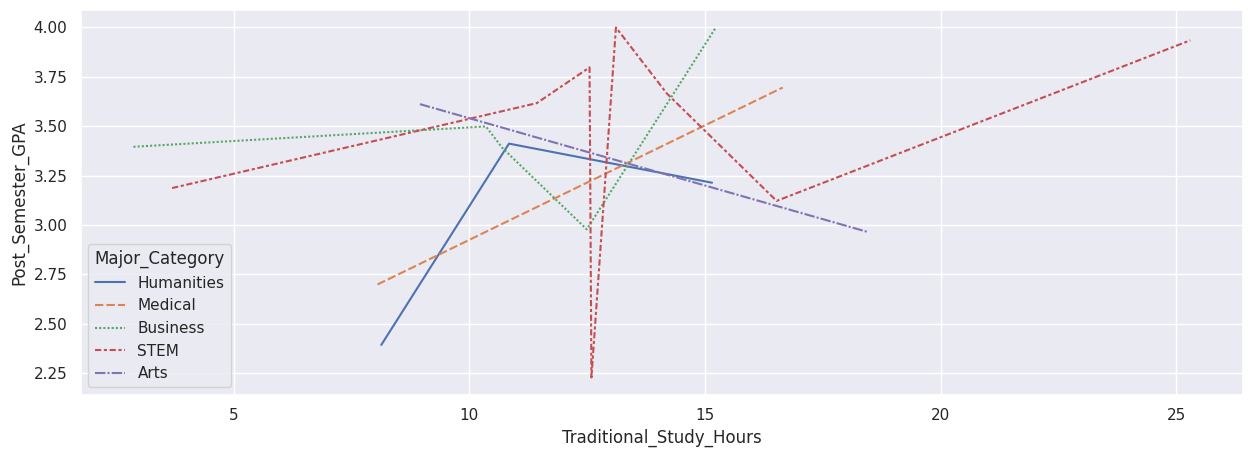

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
sns.set(color_codes=True)

data = pd.read_csv('/content/ai_student_impact_dataset (1).csv')
#sns.relplot(x = "Traditional_Study_Hours", y = "Post_Semester_GPA",kind = 'line',col = 'Major_Category',style = 'Anxiety_Level_During_Exams',hue = "Major_Category", data = data.head(50))
plt.figure(figsize=(15,5))
sns.lineplot(x = "Traditional_Study_Hours", y = "Post_Semester_GPA",style = 'Major_Category',hue = "Major_Category", data = data.head(20))
plt.show()


# **Practice**

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
sns.set(color_codes=True)
sns.palettes.SEABORN_PALETTES
sns.color_palette()
sns.set_palette("Set2")
sns.set_style("ticks")
#sns.set_context("talk")
sns.set_context(
    "talk",
    font_scale=1.3
)

# **Relational Plots**

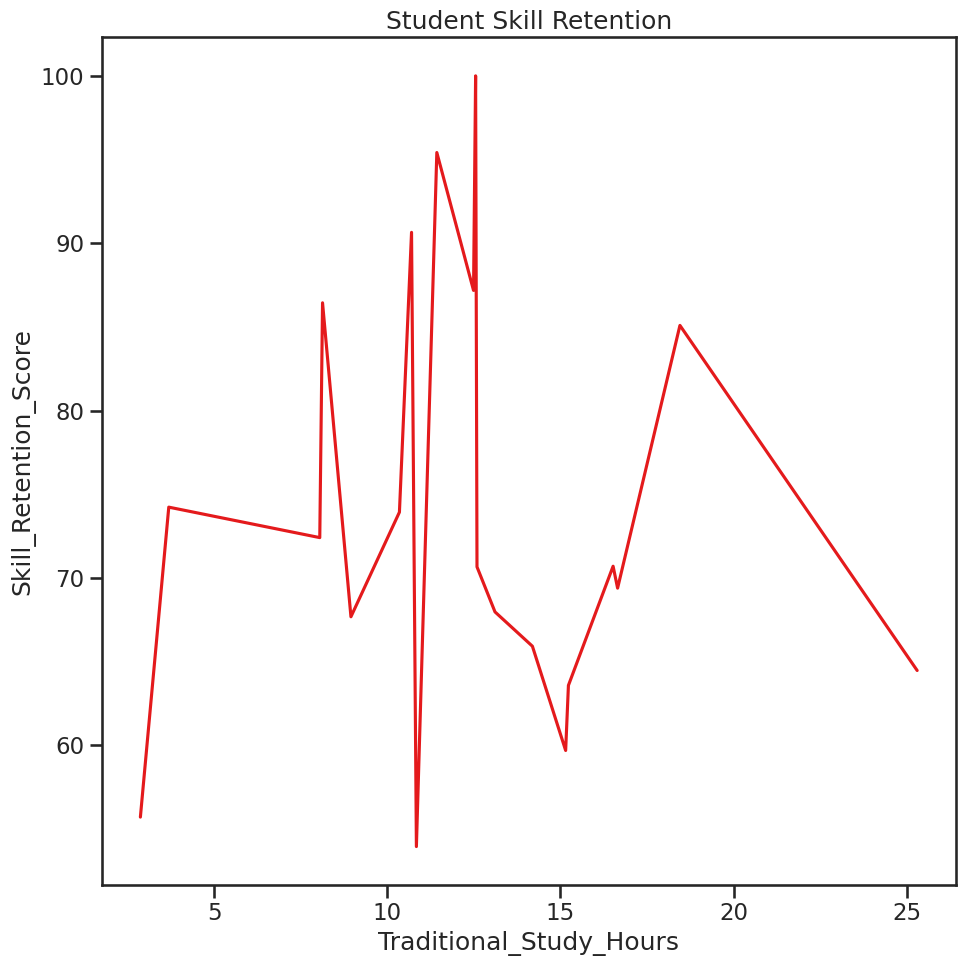

In [ ]:
sns.set_theme(
    style="ticks",
    palette="Set1",
    context="talk"
)

df = pd.read_csv('/content/ai_student_impact_dataset (1).csv')

plt.figure(figsize=(10,10))

sns.lineplot(                     #Also Scatter Plot
    data=df.head(20),
    x="Traditional_Study_Hours",
    y="Skill_Retention_Score",
    # hue="Major_Category",
    # style = "Year_of_Study",
    # size='Post_Semester_GPA',
)

plt.title("Student Skill Retention")
plt.xlabel("Traditional_Study_Hours")
plt.ylabel("Skill_Retention_Score")

plt.tight_layout()               # Adjust spacing automatically
plt.savefig("my_plot.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
help(sns.set_theme)
sns.axes_style()

# **Distribution Plots**

<Axes: xlabel='Pre_Semester_GPA', ylabel='Count'>

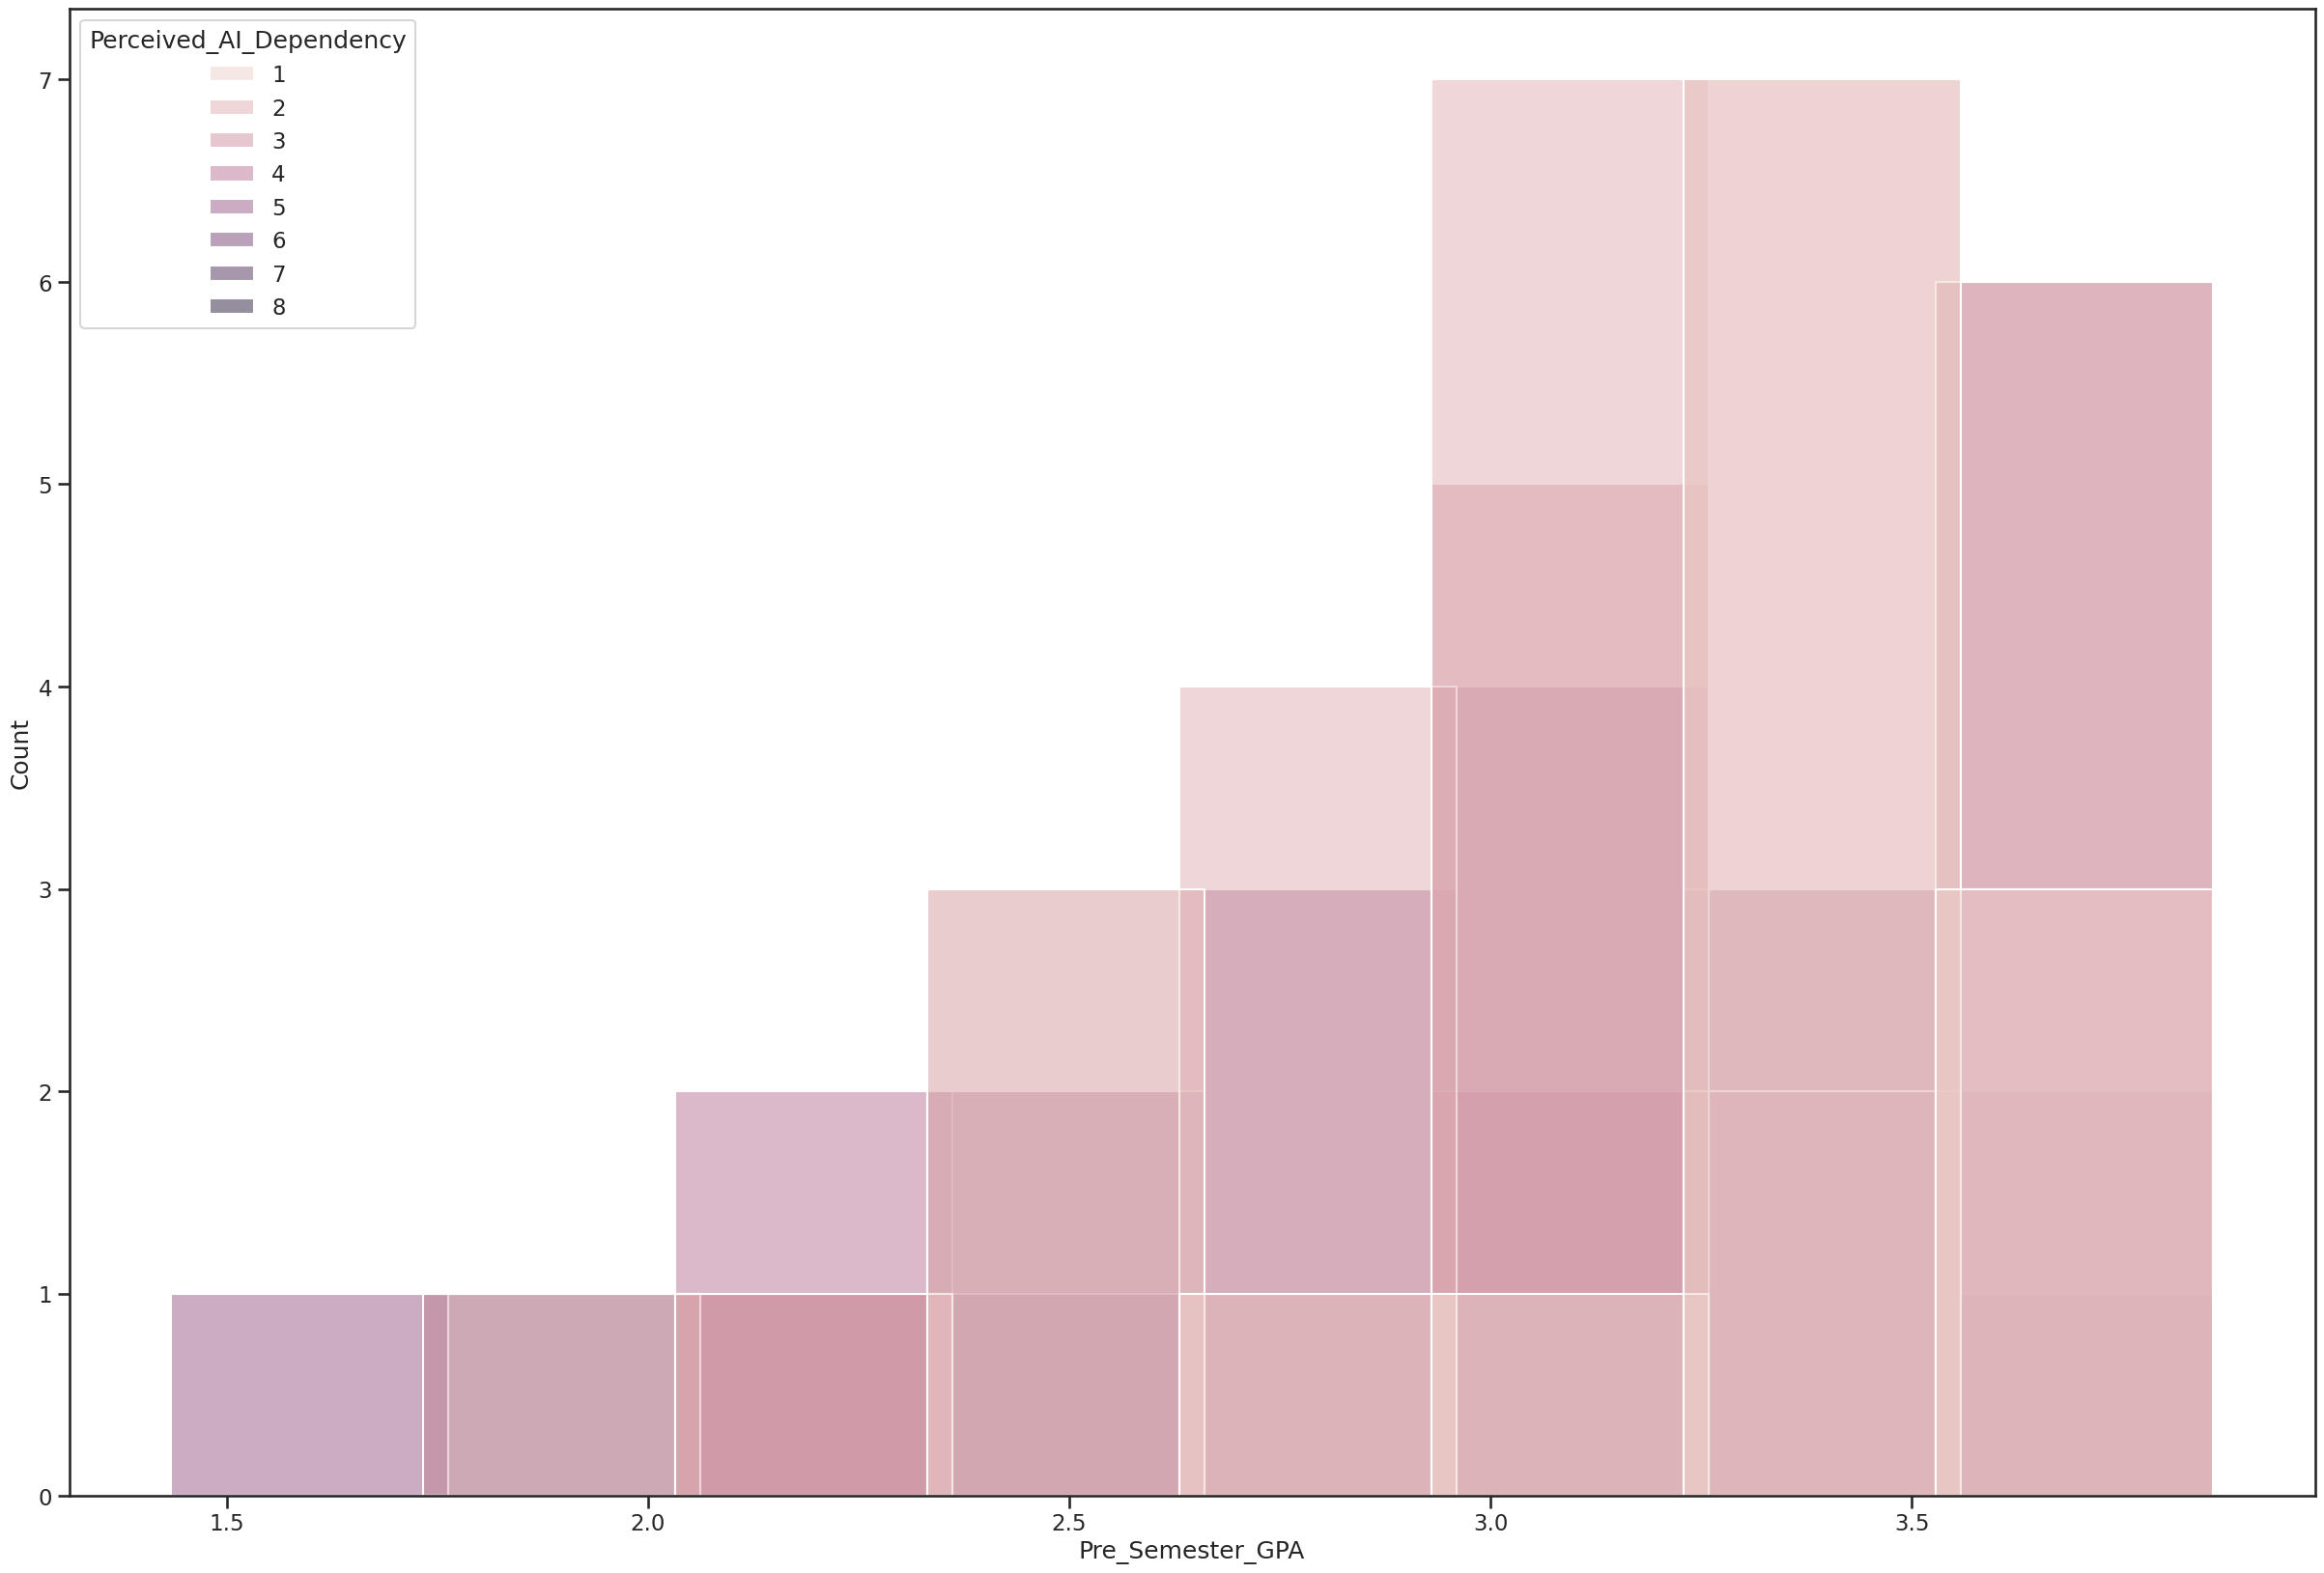

In [ ]:
plt.figure(figsize=(30,20))
df = df.head(100)
#sns.histplot(df['Post_Semester_GPA'],stat = 'frequency') #hue cannot be used here
sns.histplot(data = df, x = 'Pre_Semester_GPA', hue = 'Perceived_AI_Dependency', multiple = 'layer', element = 'bars',shrink = 1.1)

<Axes: xlabel='Pre_Semester_GPA', ylabel='Density'>

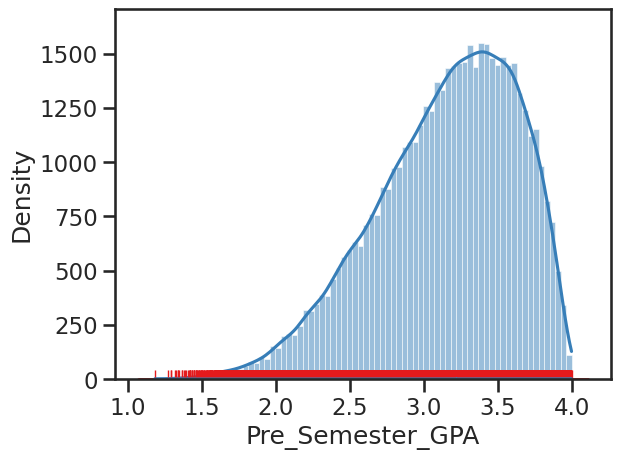

In [ ]:
sns.kdeplot(data = df, x = 'Pre_Semester_GPA', fill = True, bw_adjust=0.7)
sns.histplot(data = df, x =  'Pre_Semester_GPA', kde = True)
sns.rugplot(df['Pre_Semester_GPA'])
sns.ecdfplot(df['Pre_Semester_GPA'])

# **Categorical Plots**

<Axes: xlabel='Major_Category', ylabel='percent'>

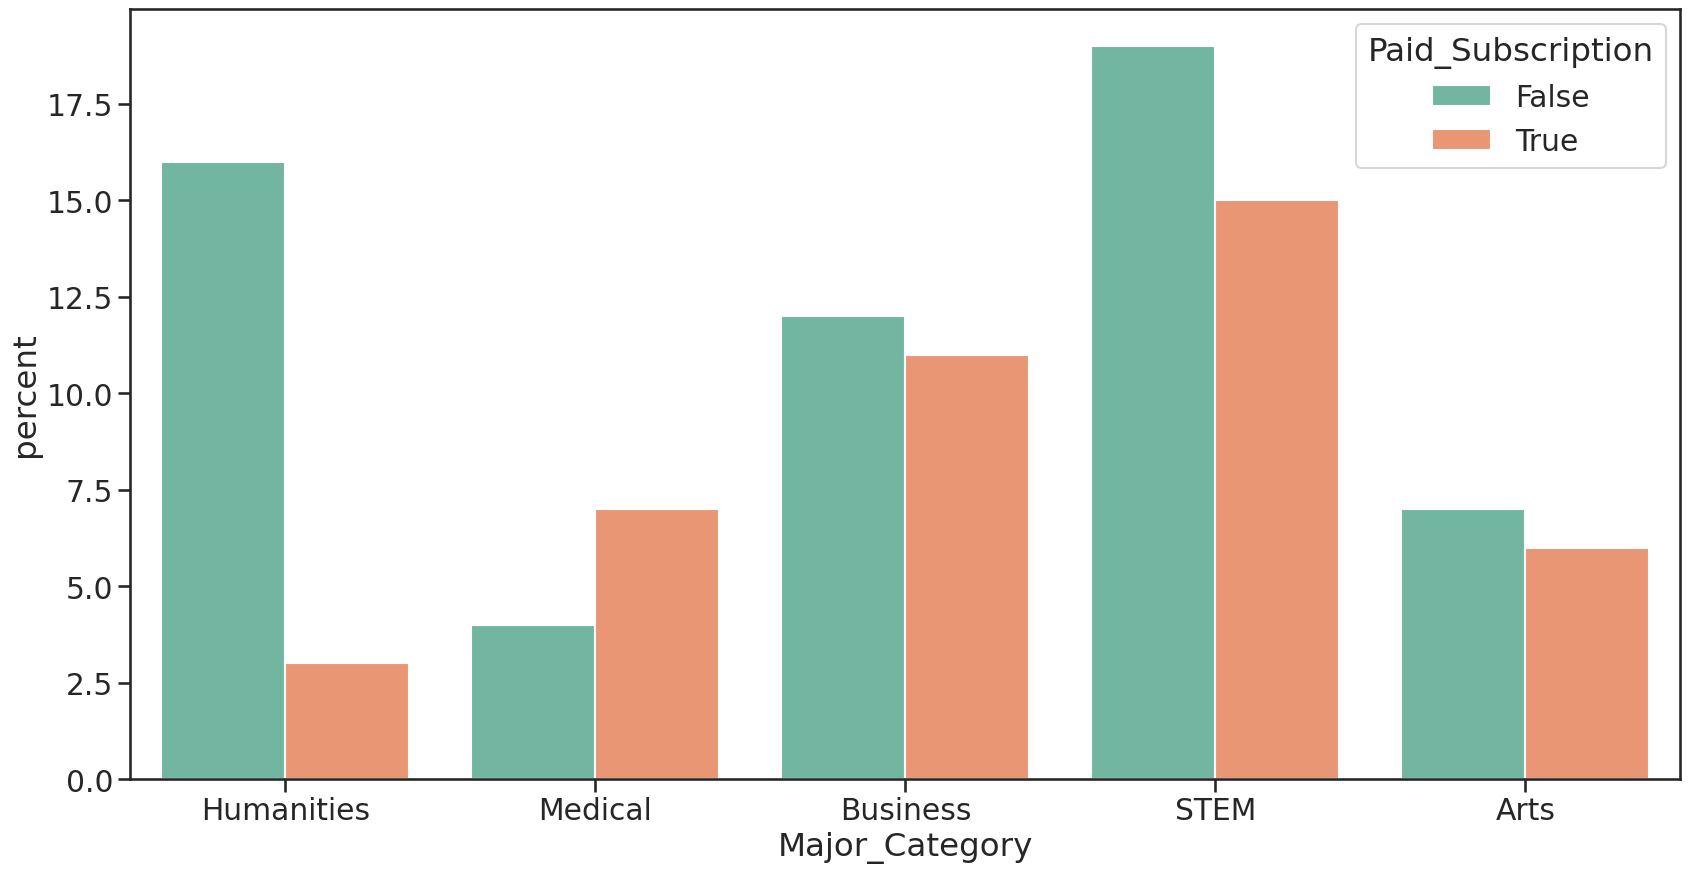

In [ ]:
plt.figure(figsize=(20,10))
sns.countplot(data = df, x ="Major_Category",hue = 'Paid_Subscription', stat='percent')

<Axes: xlabel='Major_Category', ylabel='Post_Semester_GPA'>

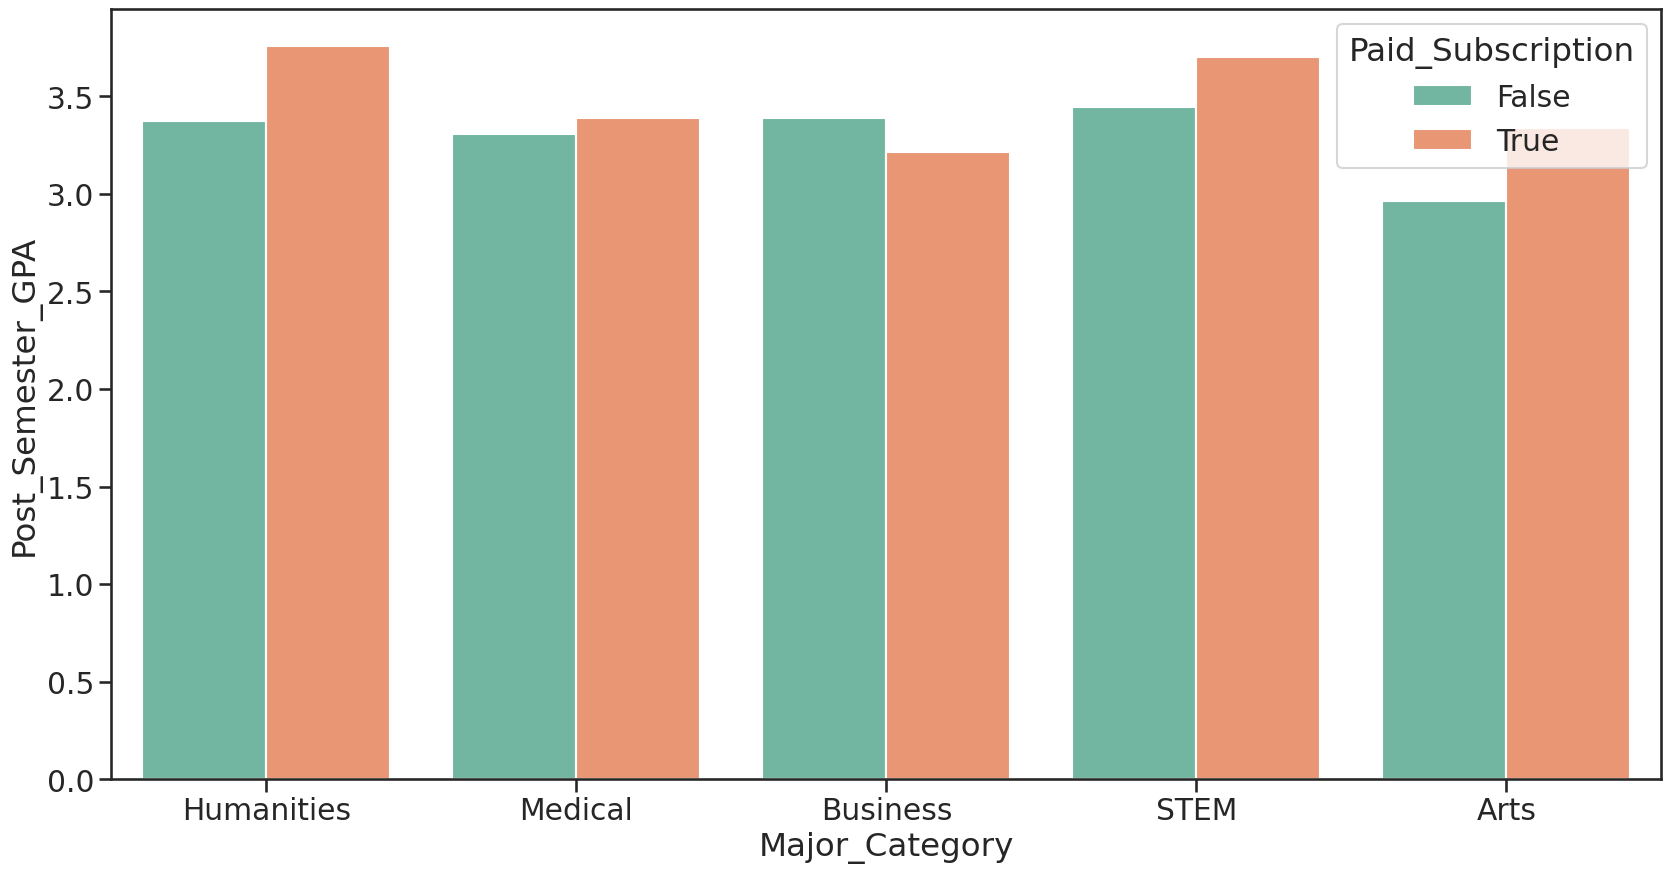

In [ ]:
plt.figure(figsize=(20,10))   # Pointplot is same but has points
sns.barplot(data = df, x ="Major_Category", y = 'Post_Semester_GPA',estimator=np.median,hue="Paid_Subscription", errorbar=None )

<Axes: xlabel='Major_Category', ylabel='Post_Semester_GPA'>

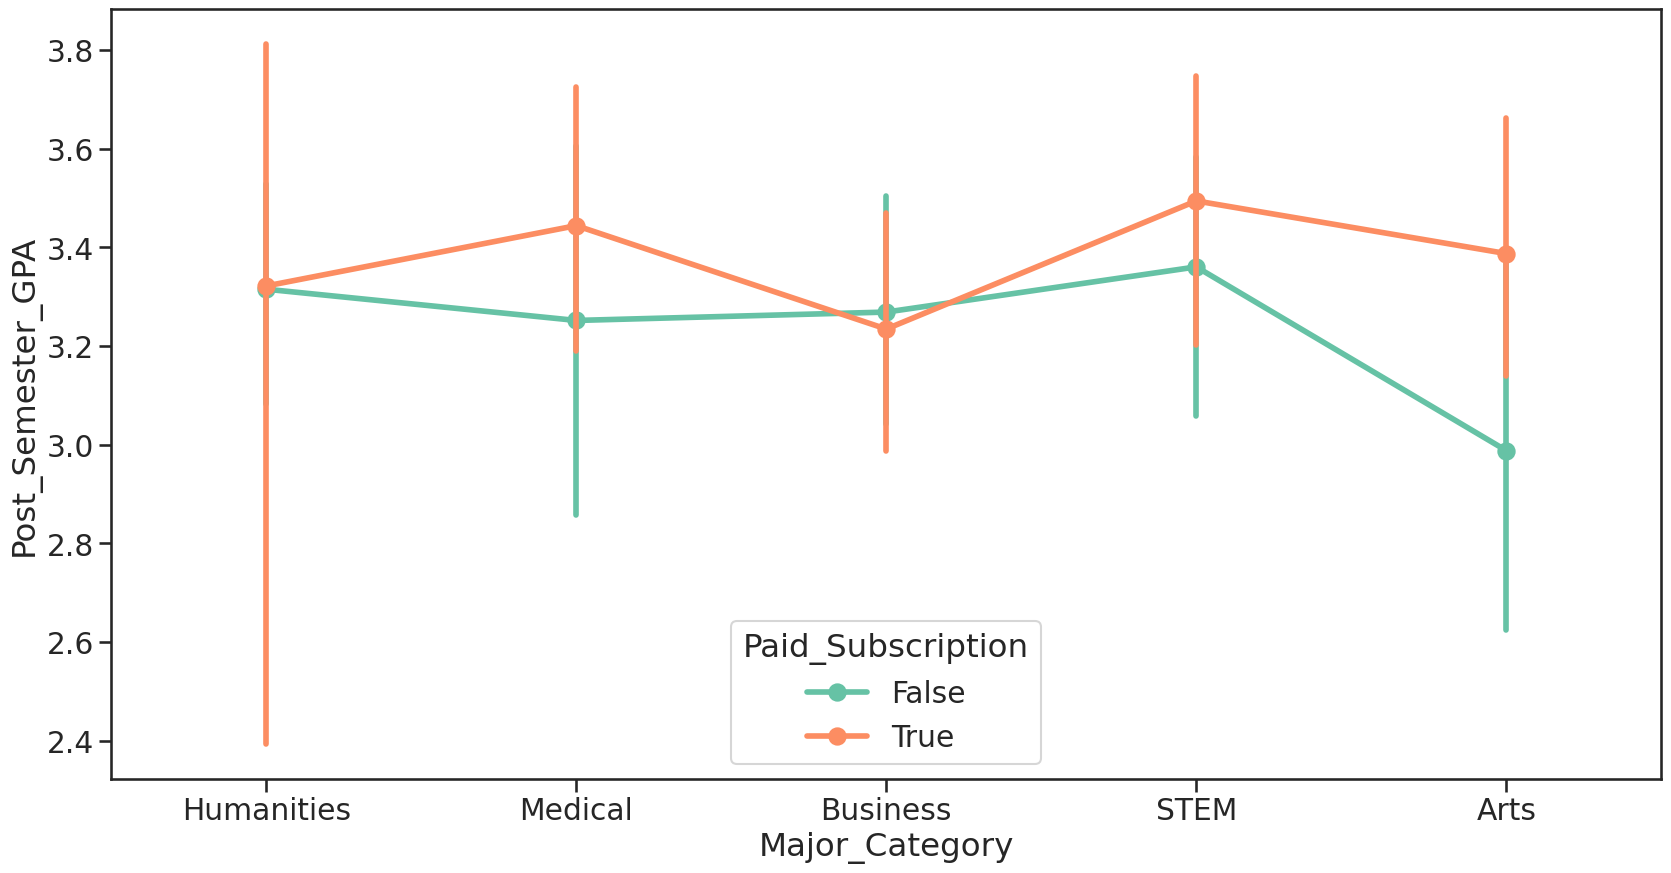

In [ ]:
plt.figure(figsize=(20,10))
sns.pointplot(data = df, x ="Major_Category", y = 'Post_Semester_GPA' ,hue="Paid_Subscription")

<Axes: xlabel='Major_Category', ylabel='Post_Semester_GPA'>

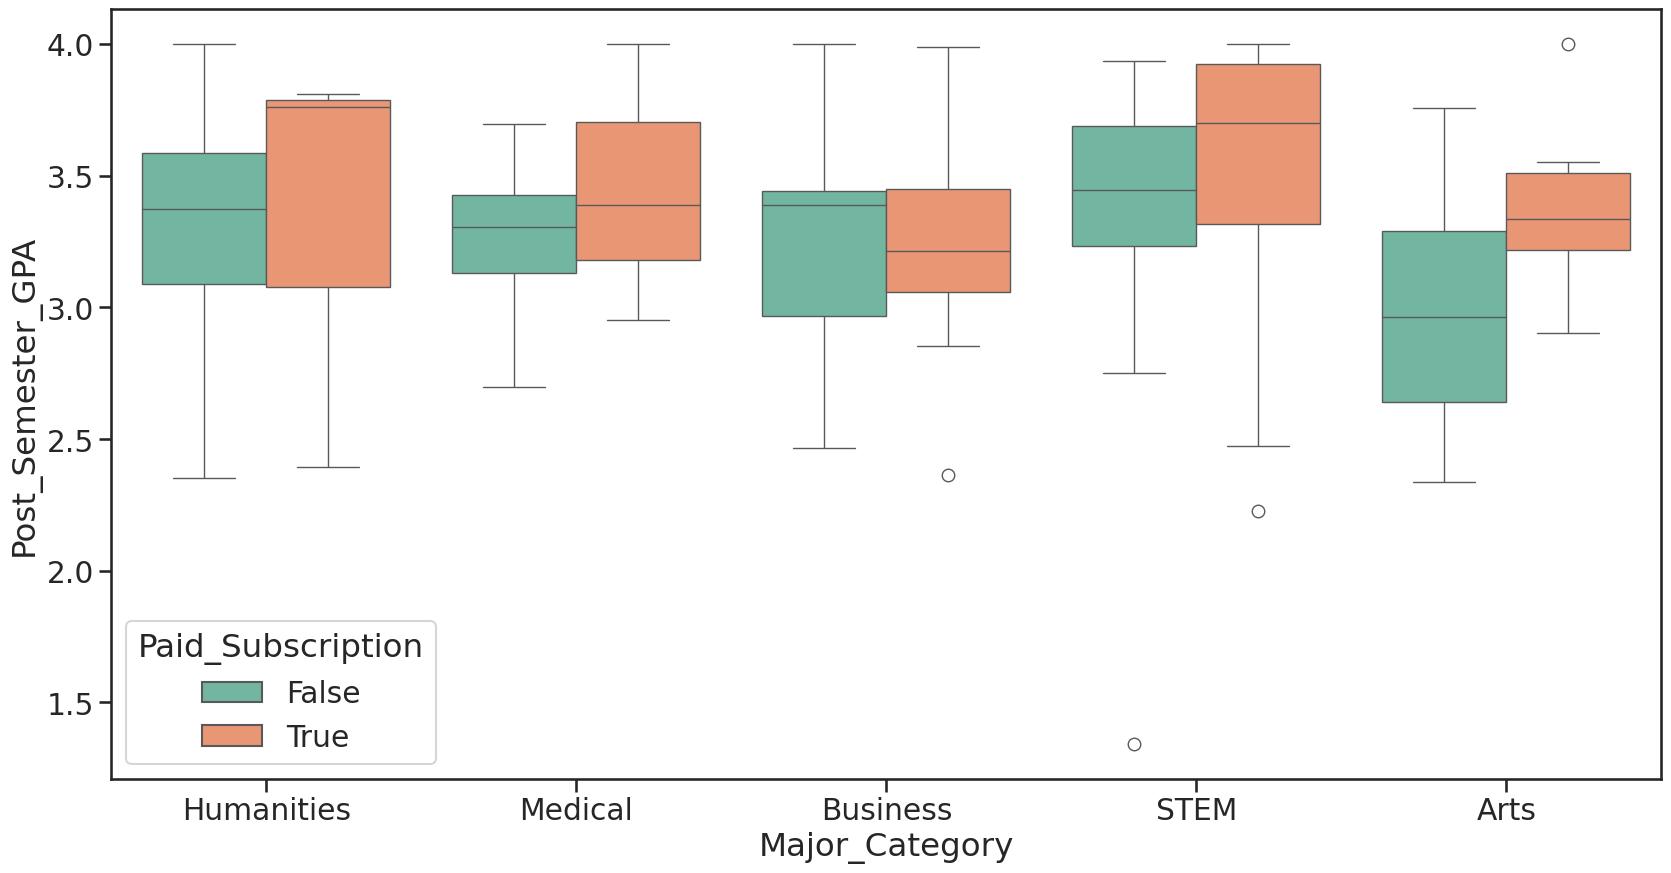

In [ ]:
plt.figure(figsize=(20,10))
sns.boxplot(data = df, x ="Major_Category", y = 'Post_Semester_GPA',hue="Paid_Subscription",)

<Axes: xlabel='Major_Category', ylabel='Post_Semester_GPA'>

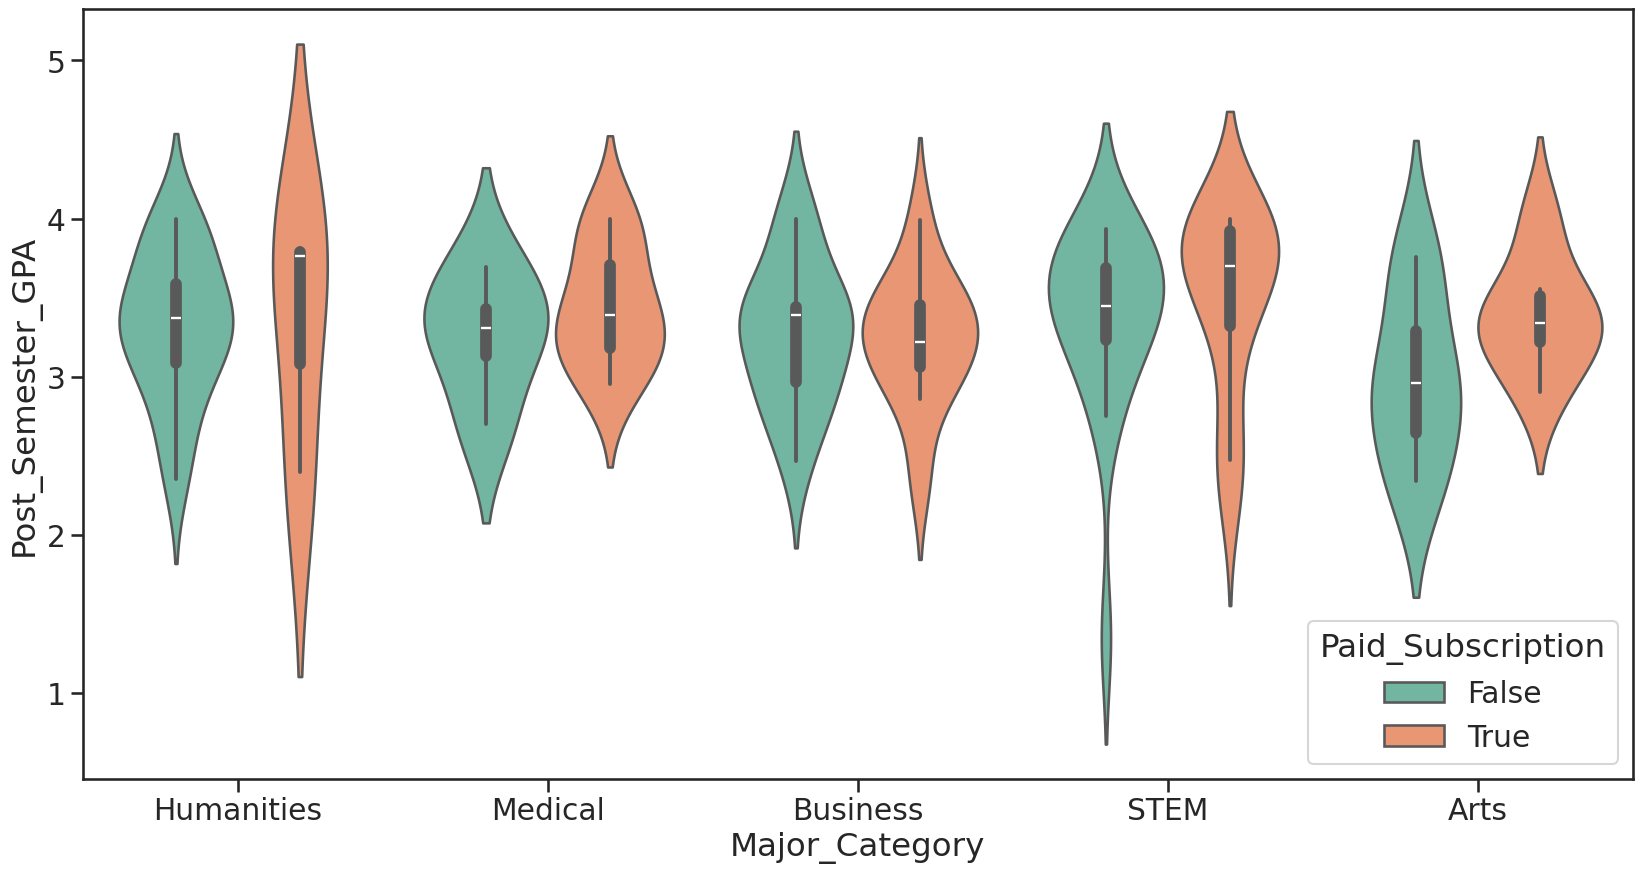

In [ ]:
plt.figure(figsize=(20,10))
sns.violinplot(data = df, x ="Major_Category", y = 'Post_Semester_GPA',hue="Paid_Subscription",)

<Axes: xlabel='Major_Category', ylabel='Post_Semester_GPA'>

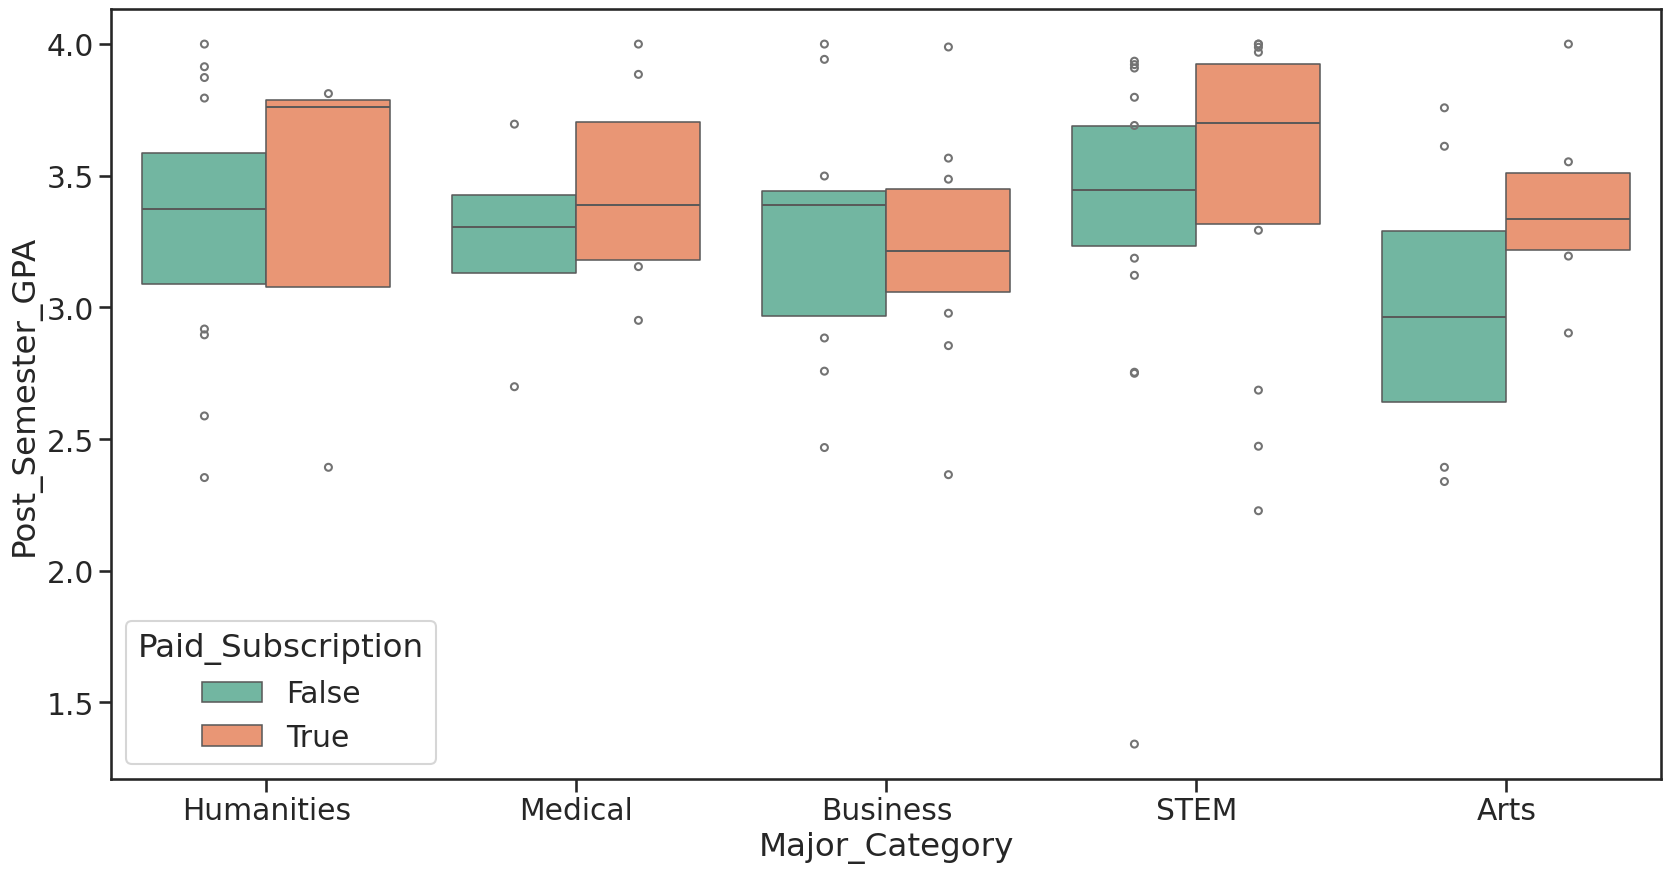

In [ ]:
plt.figure(figsize=(20,10))
sns.boxenplot(data = df, x ="Major_Category", y = 'Post_Semester_GPA',hue="Paid_Subscription",)

<Axes: xlabel='Major_Category', ylabel='Post_Semester_GPA'>

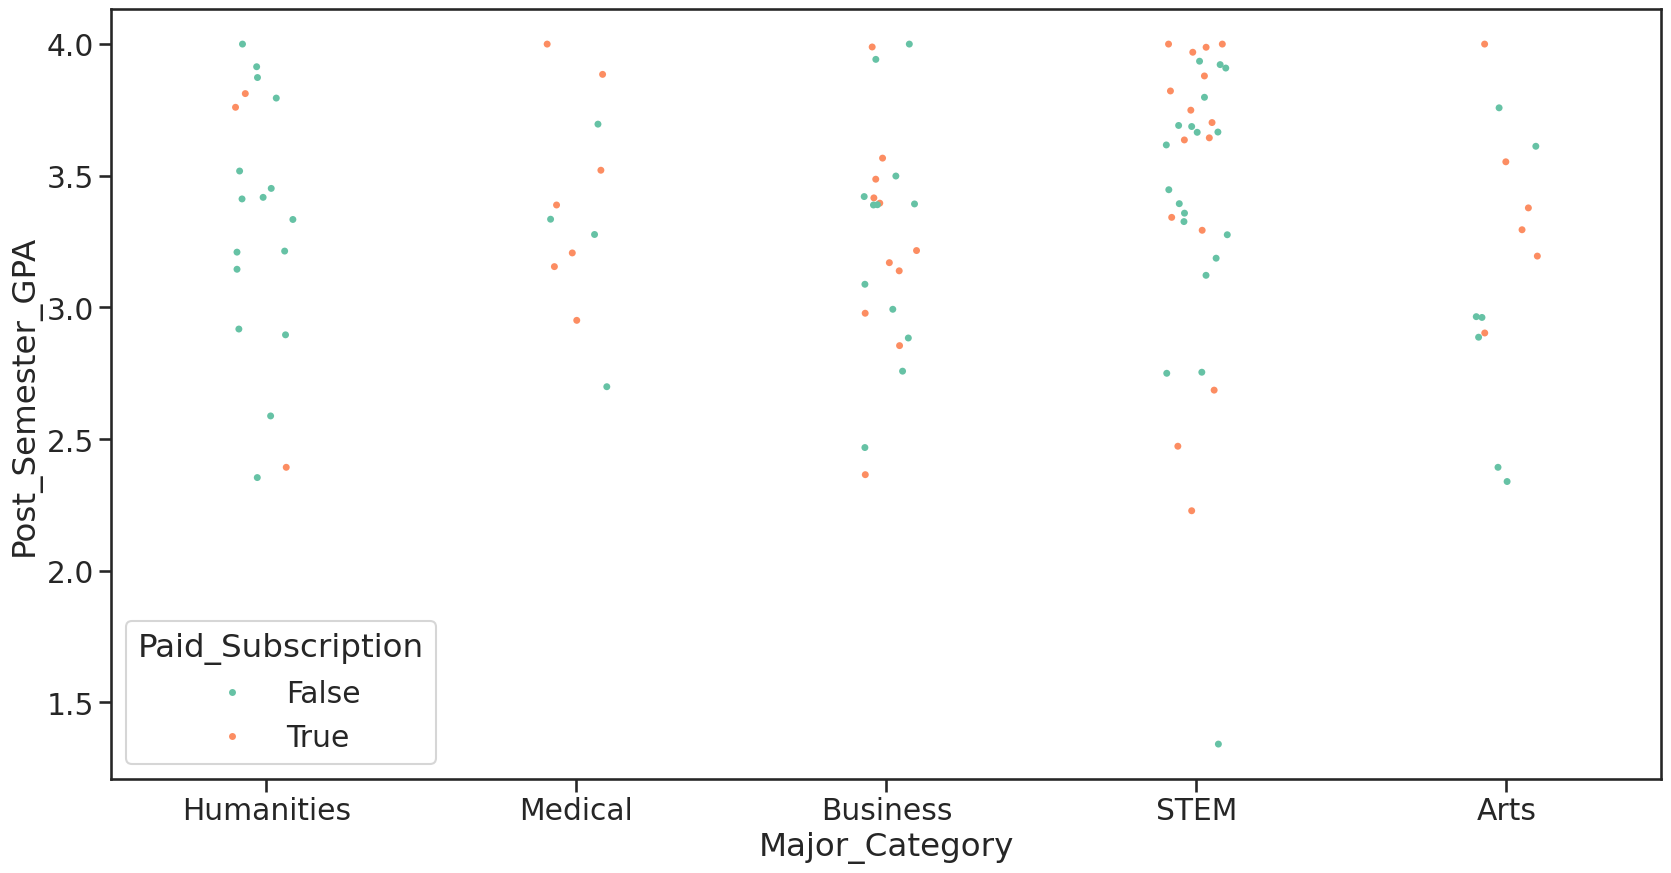

In [ ]:
plt.figure(figsize=(20,10))
sns.stripplot(data = df, x ="Major_Category", y = 'Post_Semester_GPA',hue="Paid_Subscription", jitter=True)

<Axes: xlabel='Major_Category', ylabel='Post_Semester_GPA'>

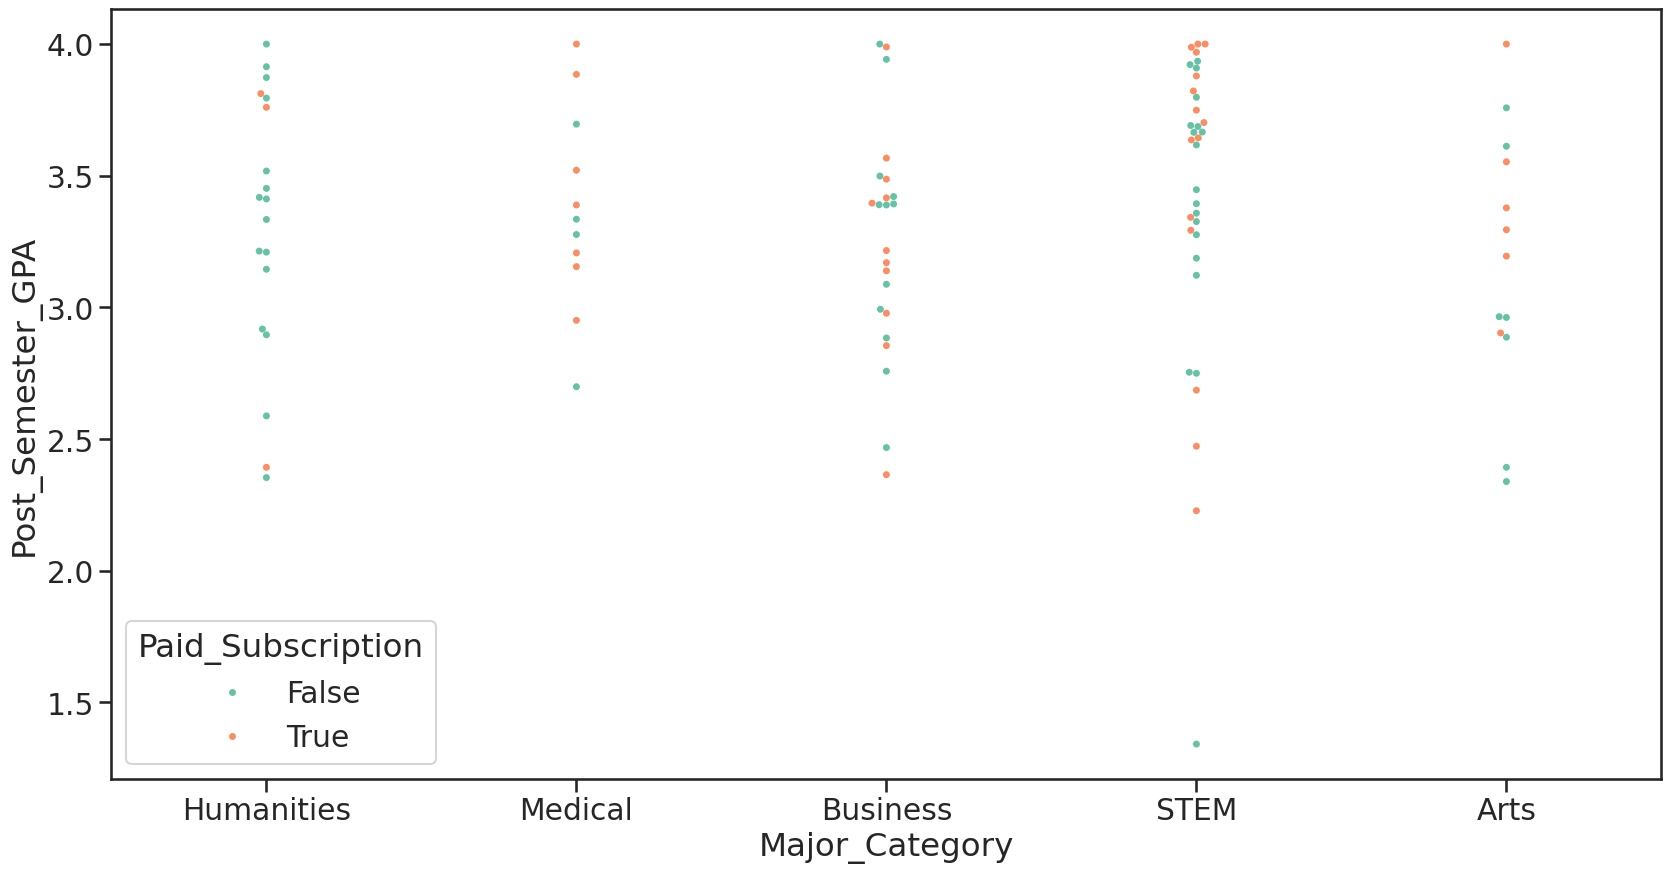

In [ ]:
plt.figure(figsize=(20,10))
sns.swarmplot(data = df, x ="Major_Category", y = 'Post_Semester_GPA',hue="Paid_Subscription",)

# **Matrix Plots**

<Axes: >

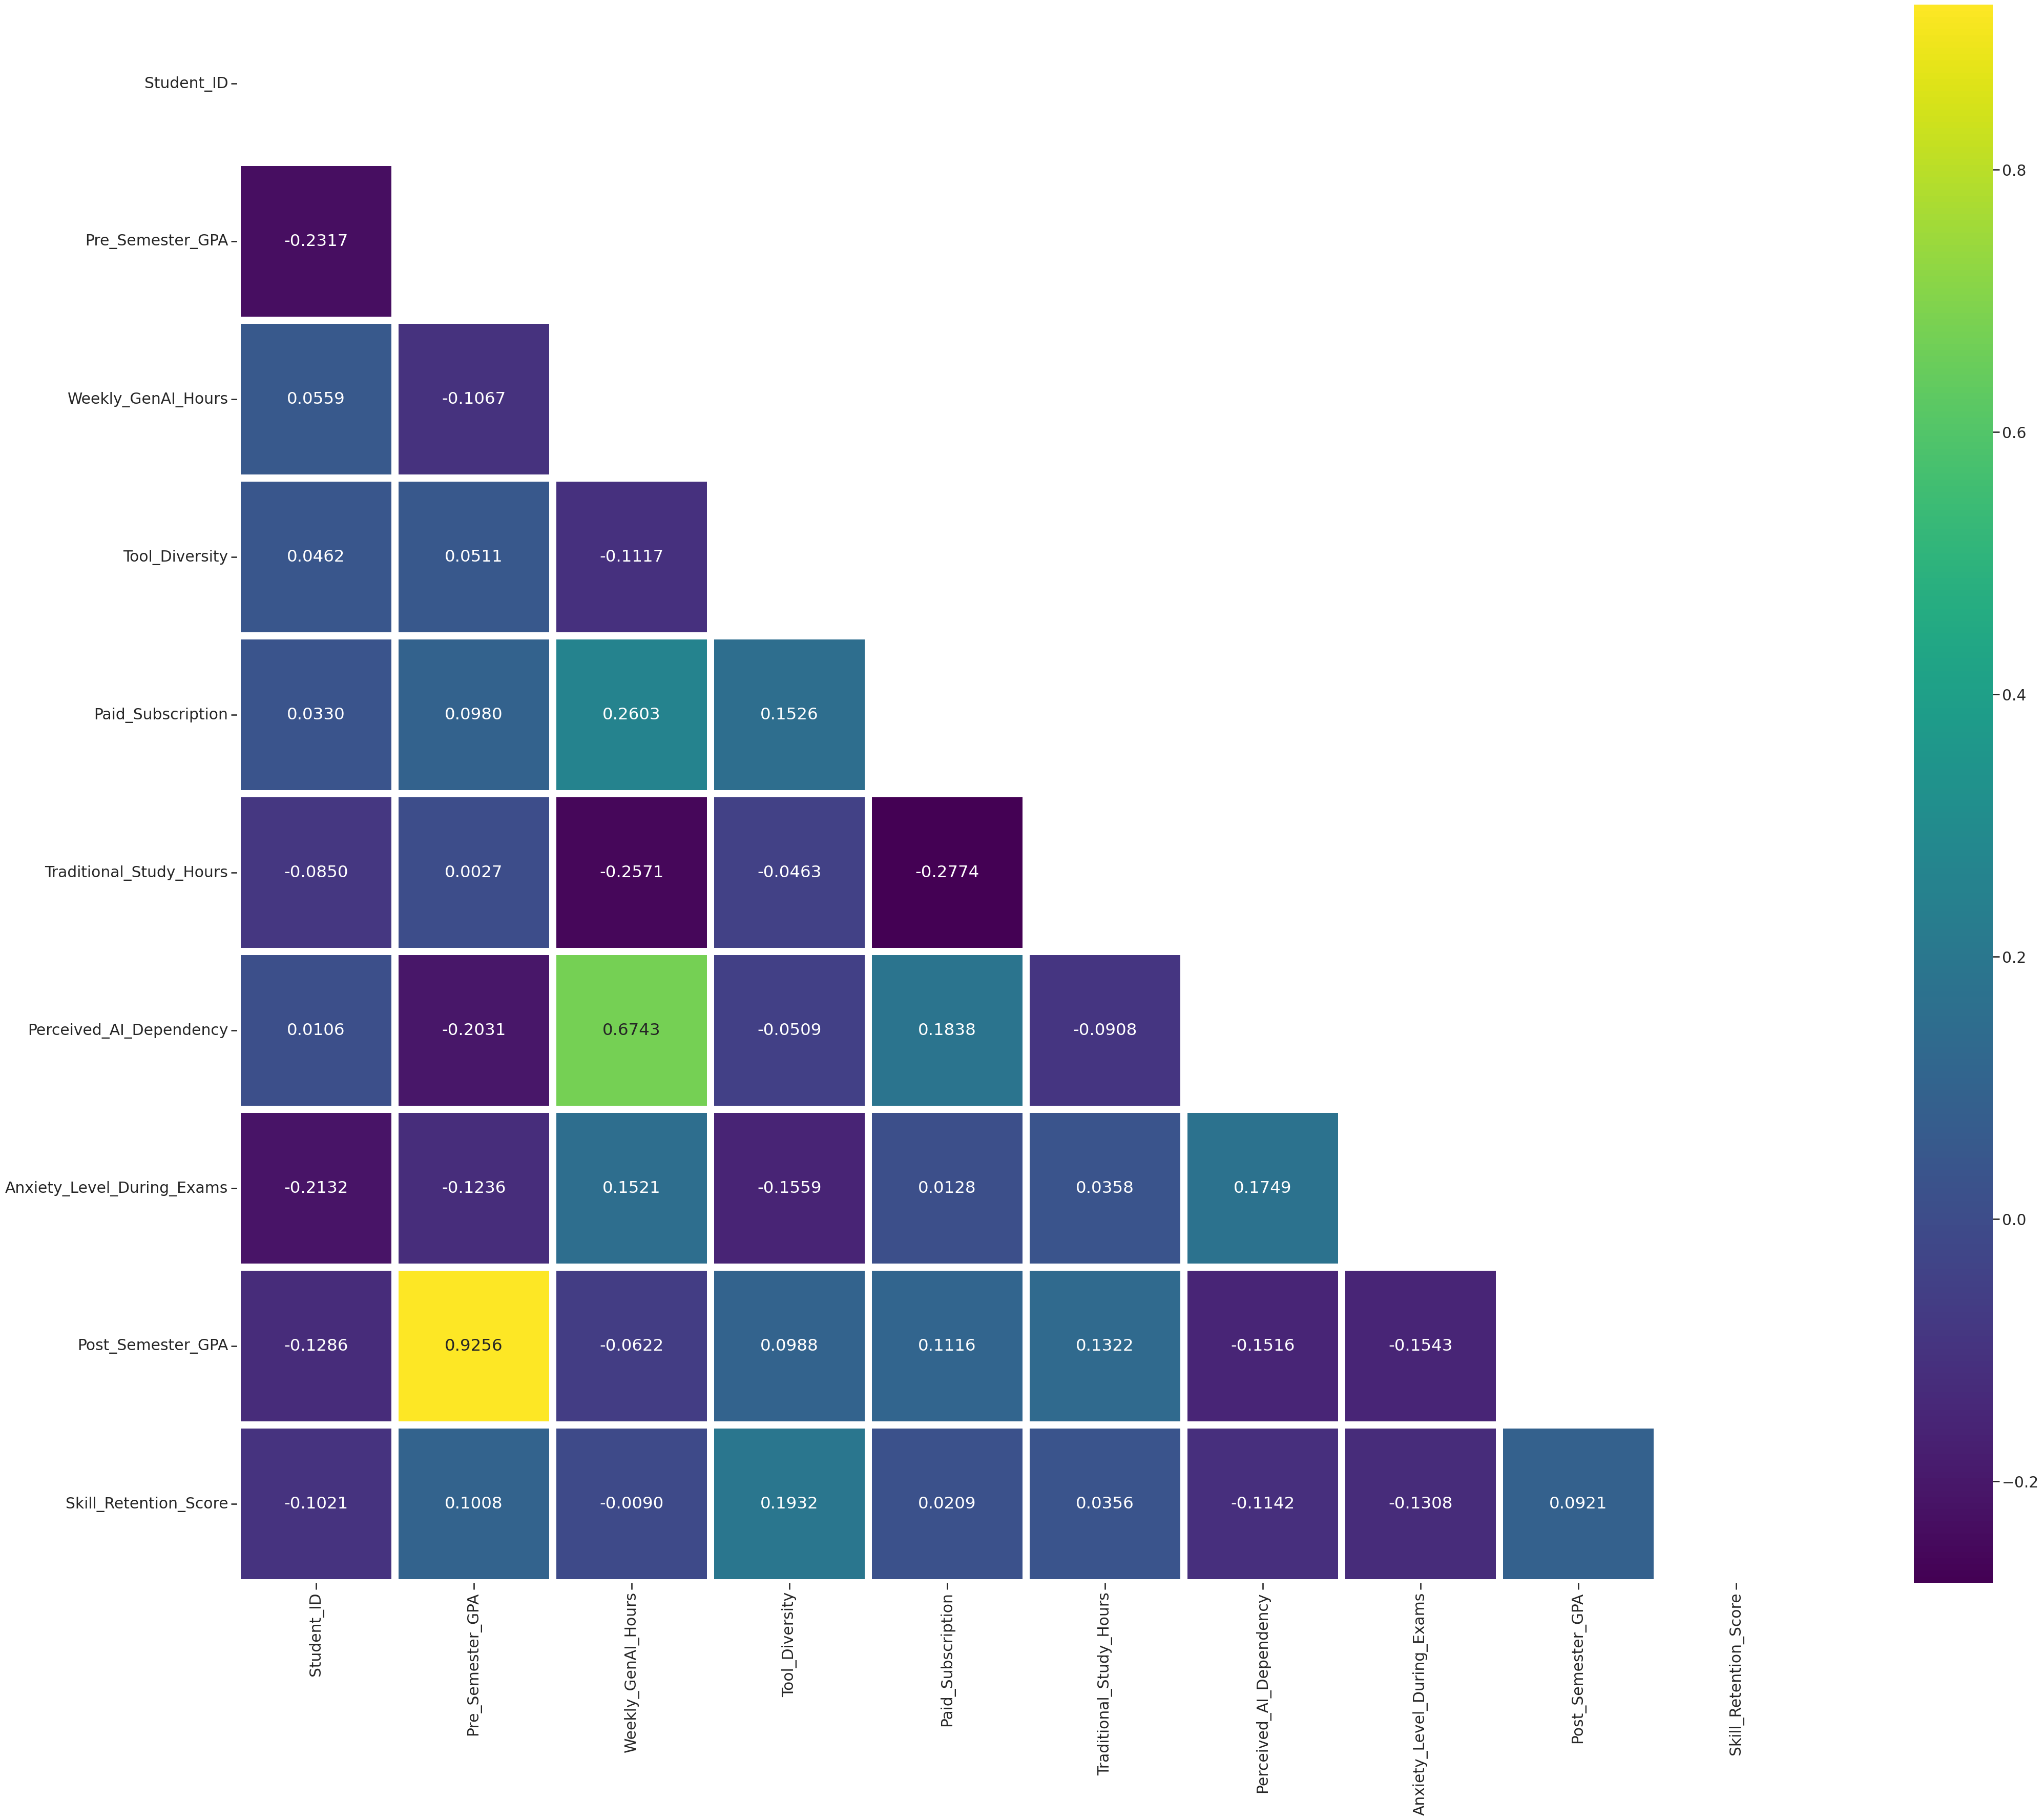

In [ ]:
plt.figure(figsize=(50,40))
corr = df.corr(numeric_only=True)
mask = np.triu(corr)
sns.heatmap( data=corr, cmap="viridis", annot=True, fmt = ".4f", linewidths=10,linecolor="white", cbar=True, square = True, mask = mask)

<Figure size 5000x4000 with 0 Axes>

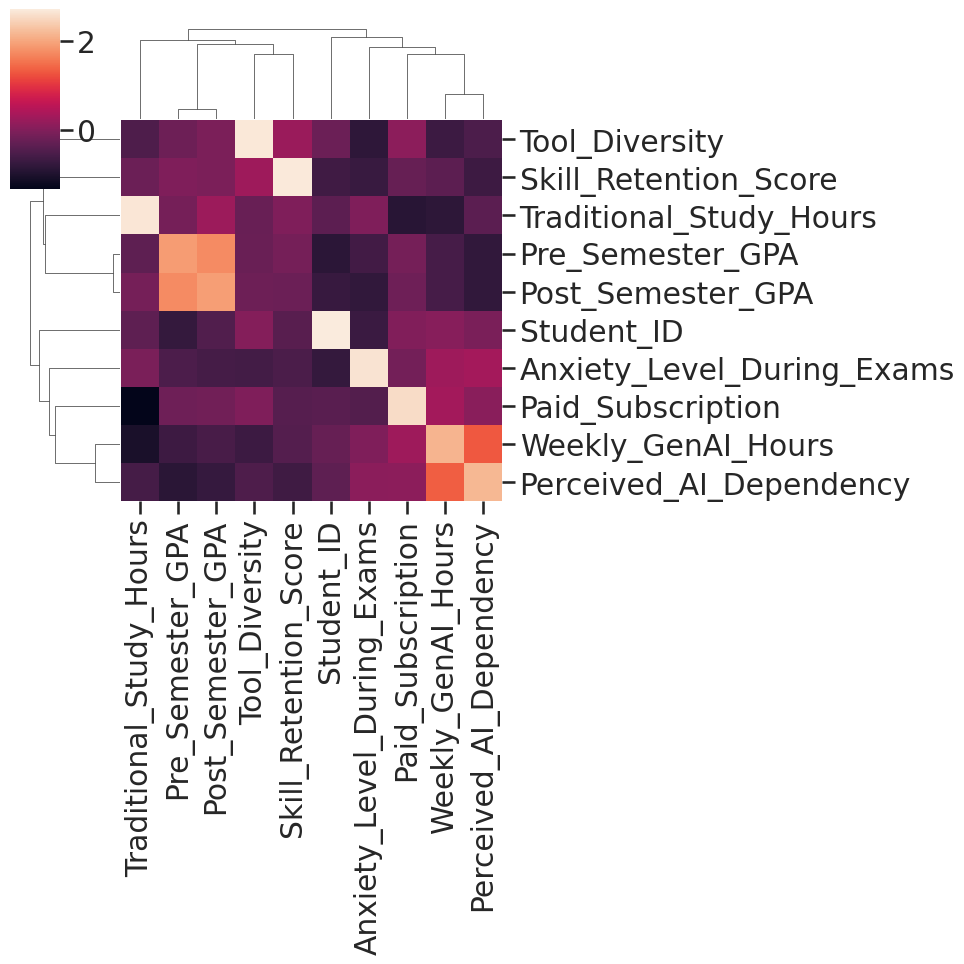

In [ ]:
plt.figure(figsize=(50,40))
sns.clustermap(data=corr.head(10), z_score=0) #either z_score or standard_Scale

# **Pairwise Relationships**

<Figure size 5000x4000 with 0 Axes>

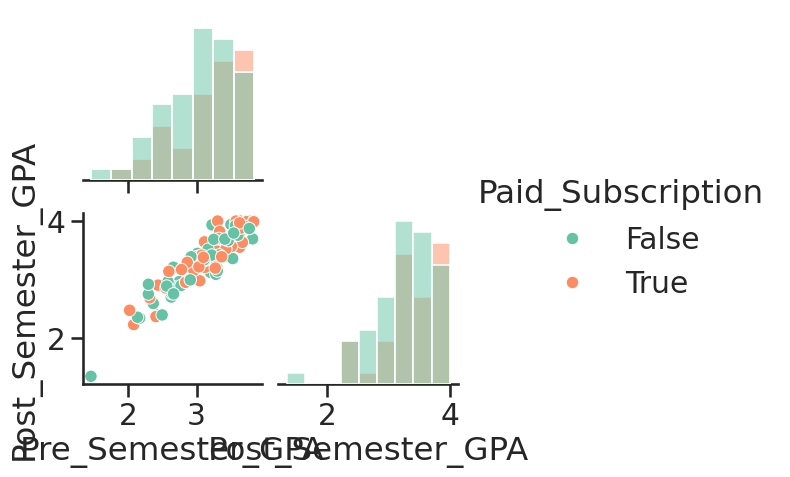

In [ ]:
plt.figure(figsize=(50,40))
sns.pairplot(
    data=df,
    hue='Paid_Subscription',
    vars=['Pre_Semester_GPA','Post_Semester_GPA'],
    kind='scatter',
    diag_kind='hist',
    corner=True
)

<Figure size 2000x1000 with 0 Axes>

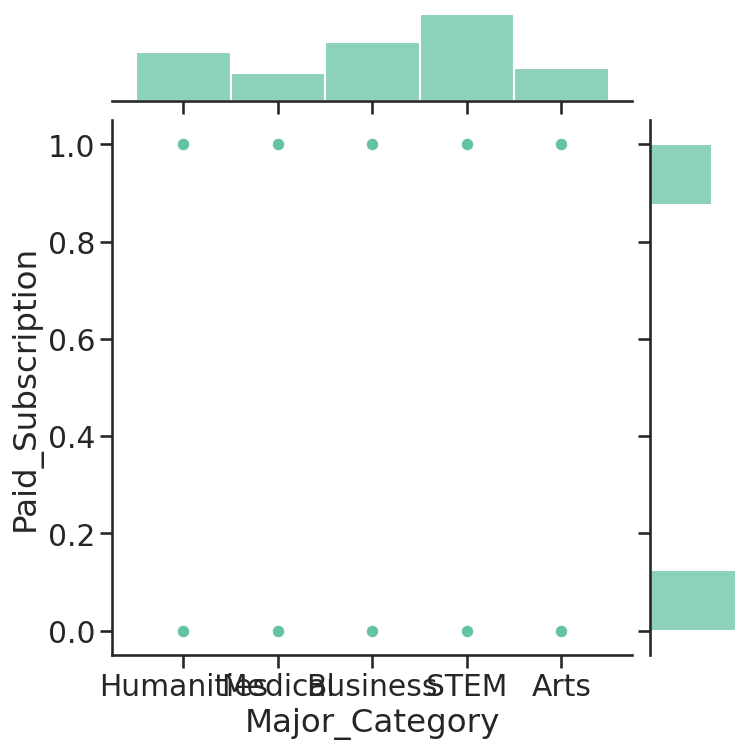

In [ ]:
plt.figure(figsize=(20,10))
sns.jointplot(
    data=df,
    x='Major_Category',
    y='Paid_Subscription',
    kind='scatter',
    height=8,
    ratio=5,
    space=0.2
)

<Axes: xlabel='Post_Semester_GPA', ylabel='Pre_Semester_GPA'>

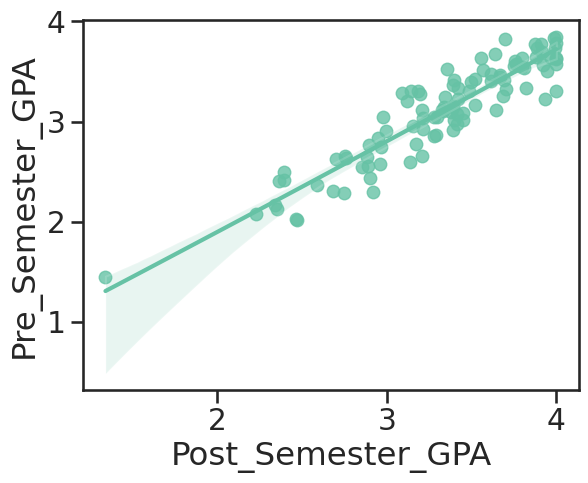

In [ ]:
sns.regplot(data = df, x = "Post_Semester_GPA", y= "Pre_Semester_GPA",  line_kws={'linewidth': 3}, order = 2, ) #robust = True

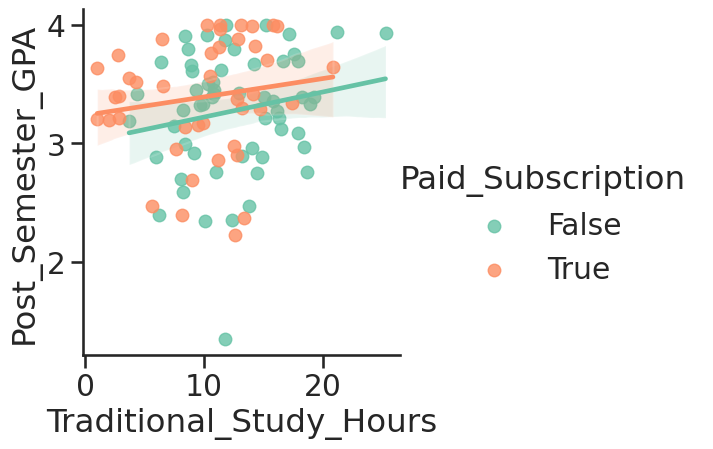

In [ ]:
sns.lmplot(
    data=df,
    x='Traditional_Study_Hours',
    y='Post_Semester_GPA',
    hue='Paid_Subscription'
)

## **EDA Workflow**

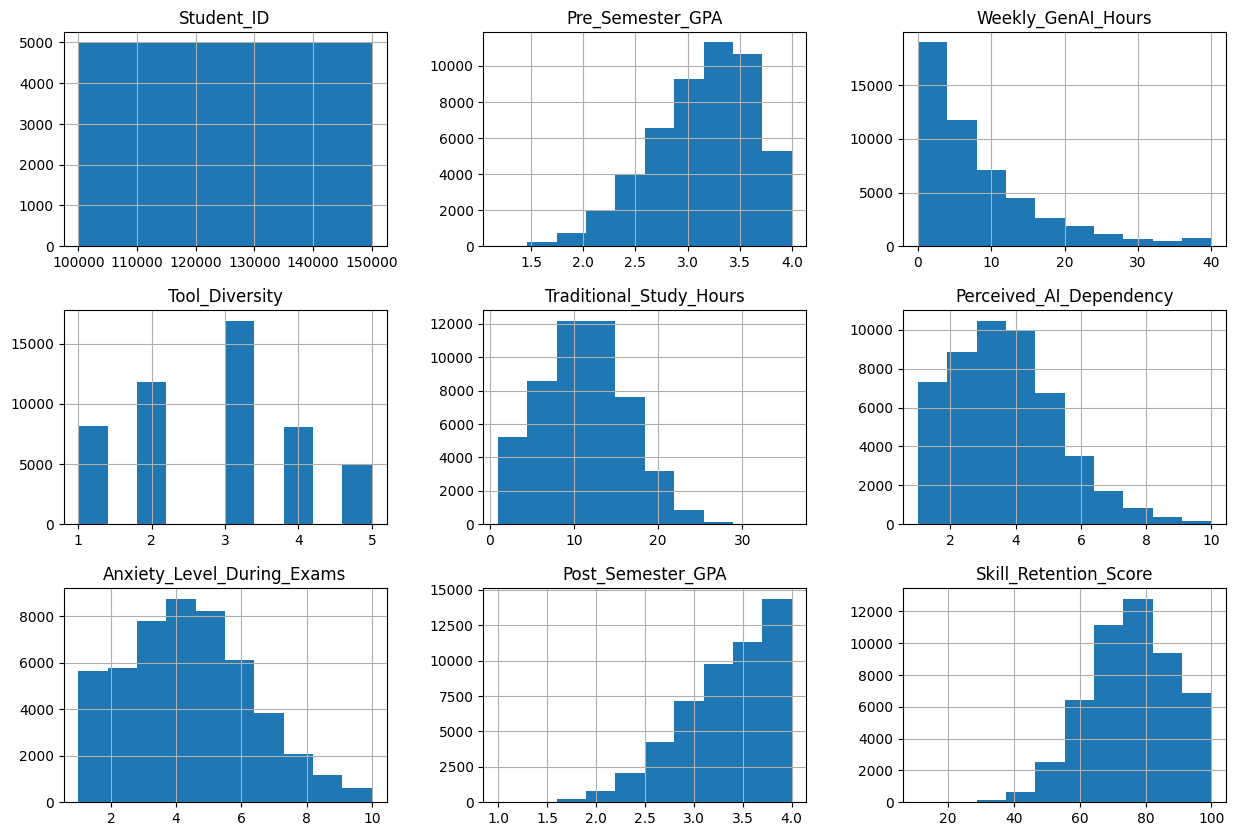

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

df = pd.read_csv('/content/ai_student_impact_dataset (1).csv')
original_df = df.copy()
#df.shape
#df.describe(include='object')
#df.describe()
#df.info()
#df.head(10)
df.sample(100)
df.dtypes
df.isnull().sum()
df[df.duplicated()]
num = df.select_dtypes(include=np.number).columns
num
cat = df.select_dtypes(include = 'object').columns
cat
df['Major_Category'].unique()
df[num].hist(figsize=(15,10))

plt.show()

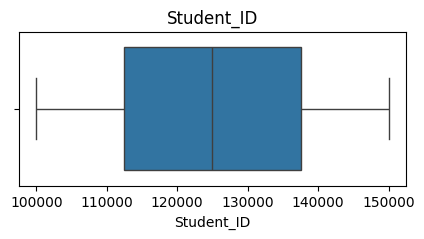

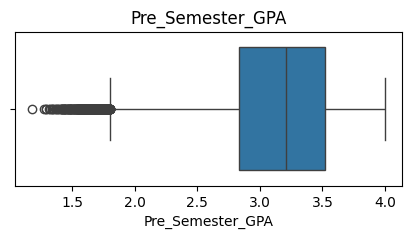

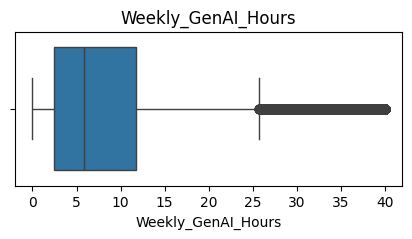

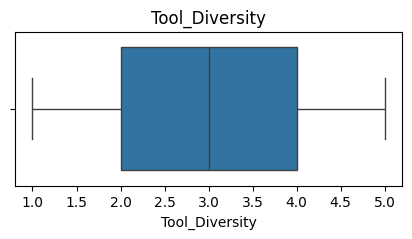

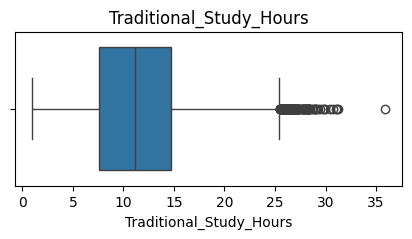

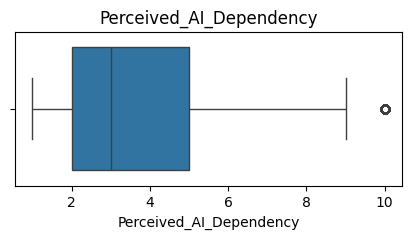

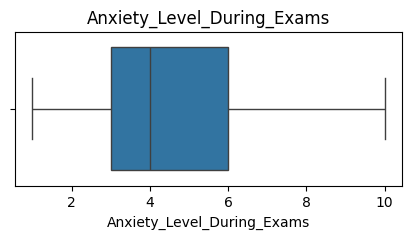

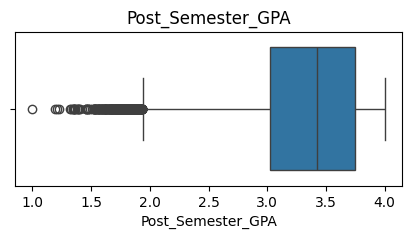

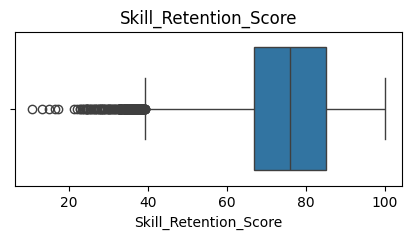

In [ ]:
for col in num:

    plt.figure(figsize=(5,2))

    sns.boxplot(x=df[col])

    plt.title(col)

    plt.show()

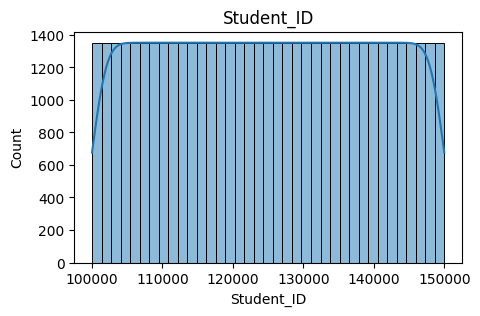

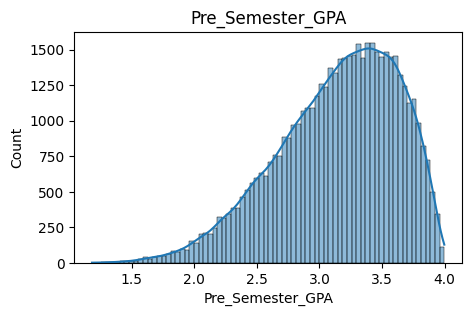

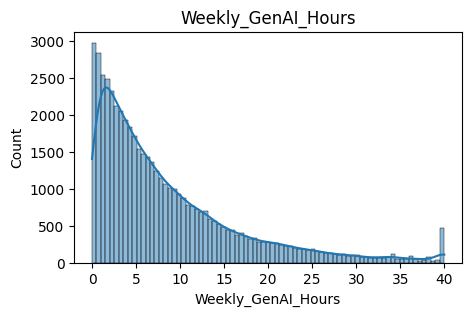

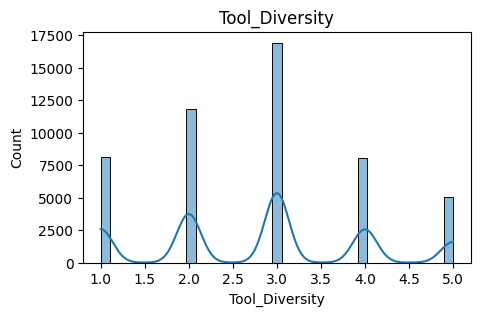

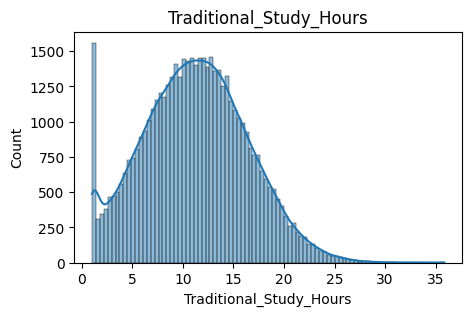

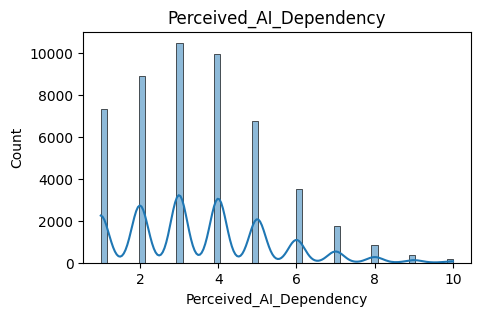

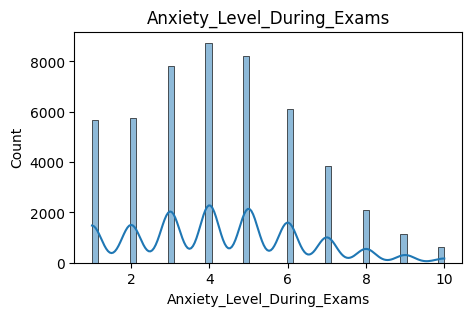

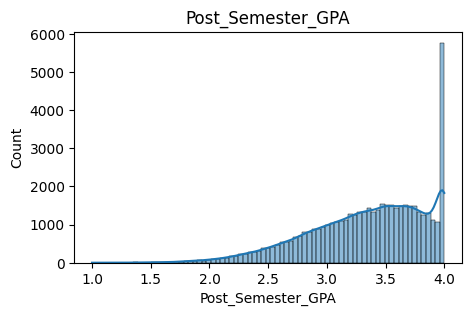

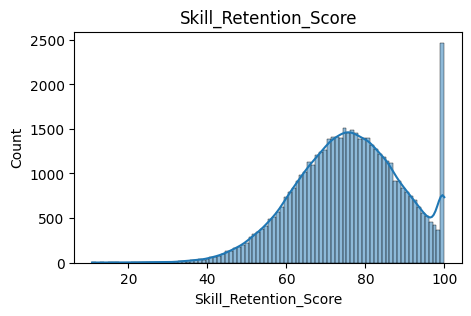

In [ ]:
for col in num:

    plt.figure(figsize=(5,3))

    sns.histplot(df[col], kde=True)

    plt.title(col)

    plt.show()

In [ ]:
df[num].skew()

,0
Student_ID,0.000000
Pre_Semester_GPA,-0.602043
Weekly_GenAI_Hours,1.609772
Tool_Diversity,0.166799
Traditional_Study_Hours,0.130072
Perceived_AI_Dependency,0.655365
Anxiety_Level_During_Exams,0.361730
Post_Semester_GPA,-0.675059
Skill_Retention_Score,-0.215181


In [ ]:
for col in num:

    Q1 = df[col].quantile(0.25)

    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR

    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print(col, len(outliers))

Student_ID 0
Pre_Semester_GPA 328
Weekly_GenAI_Hours 2583
Tool_Diversity 0
Traditional_Study_Hours 161
Perceived_AI_Dependency 190
Anxiety_Level_During_Exams 0
Post_Semester_GPA 346
Skill_Retention_Score 216


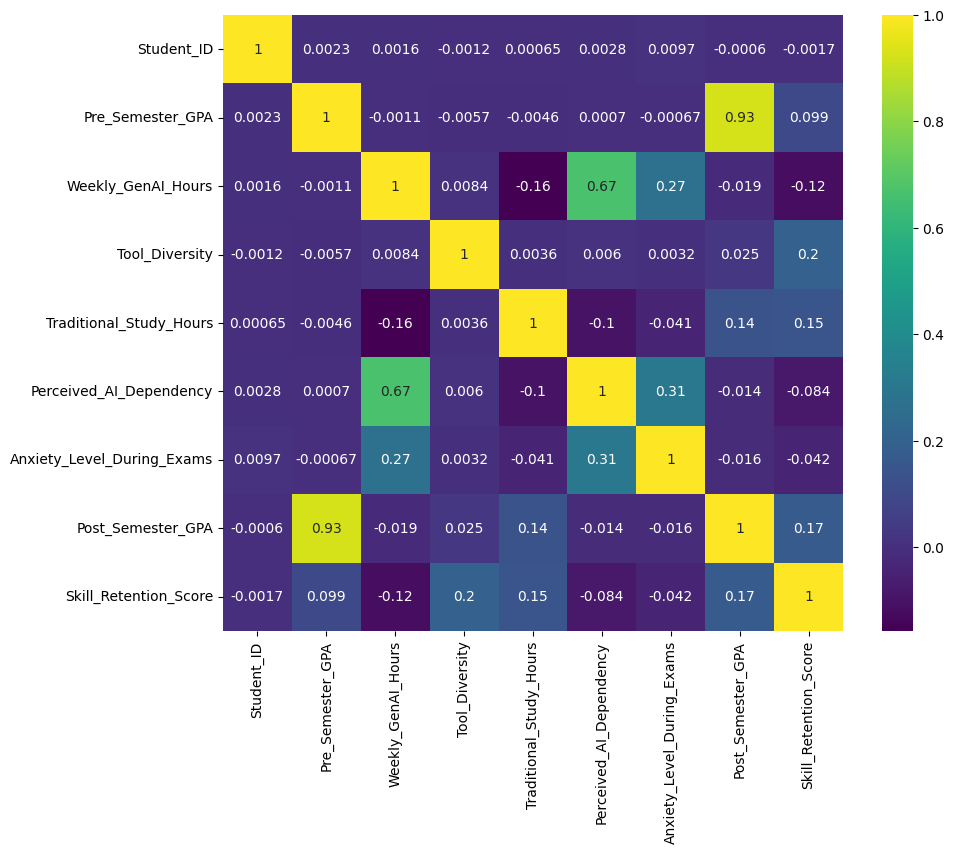

In [ ]:
corr = df[num].corr()
plt.figure(figsize=(10,8))

sns.heatmap(corr,
            annot=True,
            cmap="viridis")

plt.show()

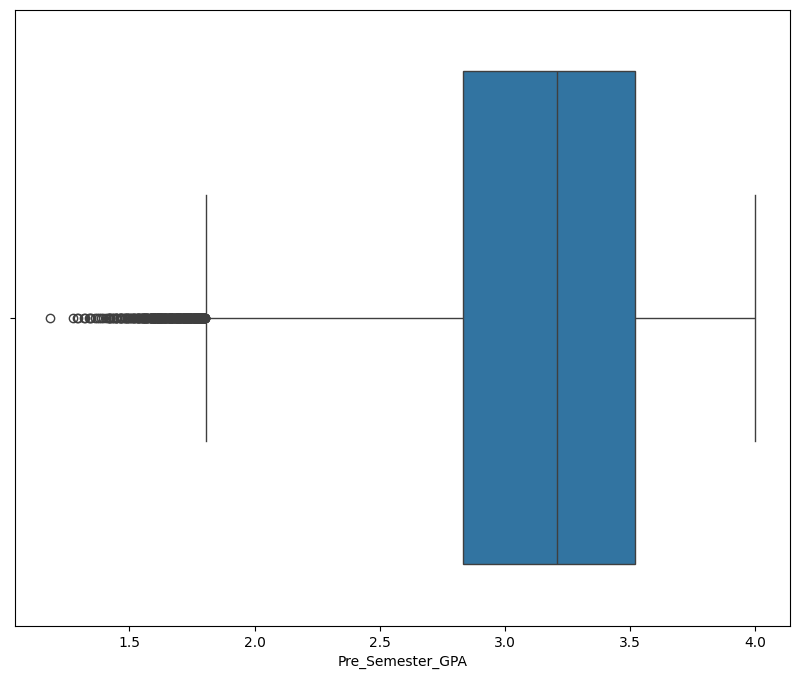

In [ ]:
plt.figure(figsize=(10,8))

sns.boxplot(data=df,x='Pre_Semester_GPA')

plt.show()

1. Load dataset
        ↓
2. Inspect dataset
        ↓
3. Identify feature types
        ↓
4. Analyze missing values
        ↓
5. Analyze duplicates
        ↓
6. Validate data types
        ↓
7. Correct invalid/inconsistent values
        ↓
8. Univariate analysis
        ↓
9. Outlier analysis
        ↓
10. Distribution analysis
        ↓
11. Bivariate analysis
        ↓
12. Correlation analysis
        ↓
13. Analyze relationship with target
        ↓
14. Domain knowledge checks
        ↓
15. Remove irrelevant columns
        ↓
16. Feature engineering
        ↓
17. Train-test split
        ↓
18. Impute missing values (fit on training set)
        ↓
19. Encode categorical variables
        ↓
20. Scale numerical features (fit on training set)
        ↓
21. Feature selection (optional)
        ↓
22. Train the machine learning model

# **Scikit Learn**

In [ ]:
#sns.heatmap(data = df.isnull(), yticklabels=False,cbar = False,cmap="viridis")
#sns.boxenplot(data = df, x = "Major_Category")
#sns.relplot(data = df.head(1000), kind='scatter', x = "Prompt_Engineering_Skill", y ='Skill_Retention_Score')
df.drop(columns=["Burnout_Risk_Level","Skill_Retention_Score"],inplace=True)
df.head(10)

,Student_ID,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA
0,100001,Humanities,Senior,2.418,23.31,Copywriting/Drafting,Beginner,1,True,8.13,5,Allowed_With_Citation,6,2.393
1,100002,Medical,Junior,3.821,1.12,Ideation,Advanced,5,False,16.65,3,Allowed_With_Citation,9,3.696
2,100003,Business,Freshman,3.398,21.26,Summarizing_Reading,Beginner,2,False,10.35,5,Strict_Ban,9,3.499
3,100004,Business,Senior,3.789,1.82,Copywriting/Drafting,Intermediate,4,False,15.23,2,Allowed_With_Citation,2,4.000
4,100005,STEM,Sophomore,3.635,9.29,Debugging/Troubleshooting,Advanced,4,False,12.55,4,Allowed_With_Citation,4,3.798
5,100006,STEM,Junior,3.449,6.50,Debugging/Troubleshooting,Beginner,1,False,14.19,4,Allowed_With_Citation,5,3.666
6,100007,STEM,Freshman,3.622,31.41,Summarizing_Reading,Advanced,5,True,13.11,8,Allowed_With_Citation,7,4.000
7,100008,Arts,Junior,2.746,5.33,Copywriting/Drafting,Intermediate,3,False,18.45,2,Actively_Encouraged,1,2.965
8,100009,Business,Sophomore,3.420,2.00,Debugging/Troubleshooting,Beginner,2,True,2.87,1,Strict_Ban,5,3.396
9,100010,Business,Sophomore,3.046,19.99,Debugging/Troubleshooting,Intermediate,2,True,12.49,3,Strict_Ban,8,2.978


In [ ]:
df.drop(columns=["Student_ID"],inplace=True)
cats = [

    "Institutional_Policy",
    "Major_Category",
    "Year_of_Study",
    "Paid_Subscription",
    "Prompt_Engineering_Skill",
    "Primary_Use_Case"
]

df = pd.get_dummies(
    df,
    columns=cats,
    drop_first=True,
    dtype=int
)



KeyError: "['Student_ID'] not found in axis"

In [ ]:

df.head(100)

,Pre_Semester_GPA,Weekly_GenAI_Hours,Tool_Diversity,Traditional_Study_Hours,Perceived_AI_Dependency,Anxiety_Level_During_Exams,Post_Semester_GPA,Institutional_Policy_Allowed_With_Citation,Institutional_Policy_Strict_Ban,Major_Category_Business,...,Year_of_Study_Junior,Year_of_Study_Senior,Year_of_Study_Sophomore,Paid_Subscription_True,Prompt_Engineering_Skill_Beginner,Prompt_Engineering_Skill_Intermediate,Primary_Use_Case_Debugging/Troubleshooting,Primary_Use_Case_Direct_Answer_Generation,Primary_Use_Case_Ideation,Primary_Use_Case_Summarizing_Reading
0,2.418,23.31,1,8.13,5,6,2.393,1,0,0,...,0,1,0,1,1,0,0,0,0,0
1,3.821,1.12,5,16.65,3,9,3.696,1,0,0,...,1,0,0,0,0,0,0,0,1,0
2,3.398,21.26,2,10.35,5,9,3.499,0,1,1,...,0,0,0,0,1,0,0,0,0,1
3,3.789,1.82,4,15.23,2,2,4.000,1,0,1,...,0,1,0,0,0,1,0,0,0,0
4,3.635,9.29,4,12.55,4,4,3.798,1,0,0,...,0,0,1,0,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,3.773,5.21,1,11.81,1,3,3.873,1,0,0,...,0,1,0,0,1,0,0,0,0,0
96,2.907,3.32,2,8.40,2,5,2.993,0,0,1,...,0,0,0,0,0,1,0,1,0,0
97,2.292,3.02,2,9.14,2,3,2.918,1,0,0,...,0,0,0,0,1,0,0,0,0,0
98,2.016,28.71,5,5.64,6,4,2.473,1,0,0,...,0,0,0,1,0,0,1,0,0,0


# **Train, Test, Split**

In [ ]:
from sklearn.model_selection import train_test_split
x = df.drop(columns=['Post_Semester_GPA'],inplace=False)
y = df['Post_Semester_GPA']
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=.20,random_state = 500)

Logistic Regression is used for classification

# **Linear Regression (Prediction)**

In [ ]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(x_train, y_train)

pred = model.predict(x_test)
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, accuracy_score
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
rmse = root_mean_squared_error(y_test, pred)
print(rmse)
print("MAE:", mean_absolute_error(y_test, pred))
print("MSE:", mean_squared_error(y_test, pred))
print("R² :", r2_score(y_test, pred))

0.16015937252471232
MAE: 0.12581090402971984
MSE: 0.02565102460750958
R² : 0.895627884000591


# **Check for Overfitting**

In [ ]:
train_r2 = model.score(x_train, y_train)
test_r2 = model.score(x_test, y_test)

print("Train R²:", train_r2)
print("Test R² :", test_r2)

Train R²: 0.8955604057459678
Test R² : 0.895627884000591


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("/content/Teen_Mental_Health_Dataset.csv")
#plt.figure(figsize=(10,10))
# df.info()
# df.describe()
# df.shape
# sns.heatmap(df.isnull(),yticklabels=False,cbar=False,cmap='viridis')
# sns.relplot(data = df, x = 'academic_performance', y = 'anxiety_level' ,kind = 'scatter')
# sns.histplot(data = df, x = 'academic_performance')
#sns.boxenplot(data = df, x = 'social_interaction_level', y = 'age')

df.head(50)

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
0,14,male,7.9,Instagram,7.4,2.9,3.01,1.5,low,2,2,1,0
1,19,female,1.9,TikTok,8.0,2.9,3.22,0.8,high,8,1,10,0
2,17,female,1.3,Instagram,7.6,0.5,3.92,0.0,high,2,4,2,0
3,15,male,7.4,TikTok,6.9,1.6,3.48,0.8,medium,1,7,9,0
4,15,female,4.7,Both,4.9,3.0,2.37,1.4,medium,3,5,2,0
5,19,female,7.4,Both,4.4,2.4,2.63,0.6,high,3,5,7,0
6,18,female,2.5,Instagram,6.4,2.4,2.63,0.7,low,2,2,5,0
7,16,male,4.0,Both,4.2,0.5,2.40,1.3,low,6,10,5,0
8,19,female,3.3,TikTok,5.0,2.1,2.04,0.9,high,1,10,9,0
9,15,male,1.9,TikTok,4.9,1.5,3.77,1.1,high,1,1,4,0


In [ ]:
# df.drop_duplicates(inplace=True)
# df.dropna(inplace=True, axis = 0)
# df = pd.get_dummies(
#     data = df,
#     columns=['gender','social_interaction_level','platform_usage'],
#     drop_first = True,
#     dtype = int
# )
df.head(20)

,age,daily_social_media_hours,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,stress_level,anxiety_level,addiction_level,depression_label,gender_male,social_interaction_level_low,social_interaction_level_medium,platform_usage_Instagram,platform_usage_TikTok
0,14,7.9,7.4,2.9,3.01,1.5,2,2,1,0,1,1,0,1,0
1,19,1.9,8.0,2.9,3.22,0.8,8,1,10,0,0,0,0,0,1
2,17,1.3,7.6,0.5,3.92,0.0,2,4,2,0,0,0,0,1,0
3,15,7.4,6.9,1.6,3.48,0.8,1,7,9,0,1,0,1,0,1
4,15,4.7,4.9,3.0,2.37,1.4,3,5,2,0,0,0,1,0,0
5,19,7.4,4.4,2.4,2.63,0.6,3,5,7,0,0,0,0,0,0
6,18,2.5,6.4,2.4,2.63,0.7,2,2,5,0,0,1,0,1,0
7,16,4.0,4.2,0.5,2.40,1.3,6,10,5,0,1,1,0,0,0
8,19,3.3,5.0,2.1,2.04,0.9,1,10,9,0,0,0,0,0,1
9,15,1.9,4.9,1.5,3.77,1.1,1,1,4,0,1,0,0,0,1


In [ ]:
from sklearn.model_selection import train_test_split
x = df.drop(columns=['academic_performance'],inplace=False)
y= df['academic_performance']
X_train, X_test, y_train, y_test = train_test_split(x,y,test_size=.20,random_state=101)
from sklearn.linear_model import LinearRegression
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)
pred = lin_reg.predict(X_test)
print("Prediction:",pred)
from sklearn.metrics import accuracy_score, mean_squared_error,root_mean_squared_error,mean_absolute_error,r2_score
accuracy = accuracy_score(y_test, pred)
print("accuracy: ", accuracy)
mse = mean_squared_error(y_test,pred)
print("MSE: ",mse)
rmse = root_mean_squared_error(y_test,pred)
print("RMSE: ",rmse)
mae = mean_absolute_error(y_test,pred)
print("MAE: ",mae)
r2 = r2_score(y_test,pred)
print("R2 :",r2)

Prediction: [3.02910486 2.91918723 2.88846122 2.96608852 3.07899225 2.99329592
 2.99324235 2.91040733 3.05710666 3.0333088  2.98077298 3.00317072
 2.96152344 3.07238741 2.96064575 3.06769881 3.06566599 2.98506673
 2.98853974 2.95754168 2.85417628 2.95374673 2.91685563 2.97011312
 3.00663928 3.03117936 3.01568988 2.94906735 3.00625782 3.02350885
 2.98234382 2.91370484 2.94997261 2.97238222 2.95826768 2.91105989
 3.06258365 2.92101014 2.98731985 2.95026052 3.09672531 3.05572327
 3.00209947 2.91689704 3.01272422 2.99146536 2.85873055 2.97436114
 2.95112421 2.99137753 3.06500333 3.00582348 3.02337448 3.02117323
 2.96545417 2.96945484 2.91685444 3.02420307 2.98329234 2.93654596
 2.92264593 3.02123208 2.88809641 3.02301447 3.05562133 3.13637002
 3.02680744 3.03645847 2.96349431 3.11336202 3.03233773 2.96228409
 2.93790581 2.93637815 2.96644199 2.95317763 2.93939738 2.89137583
 2.94748317 3.0716583  3.04992879 2.96487188 2.91837892 2.97557586
 2.94743667 3.02712063 3.01154451 3.00408918 2.930

ValueError: continuous is not supported

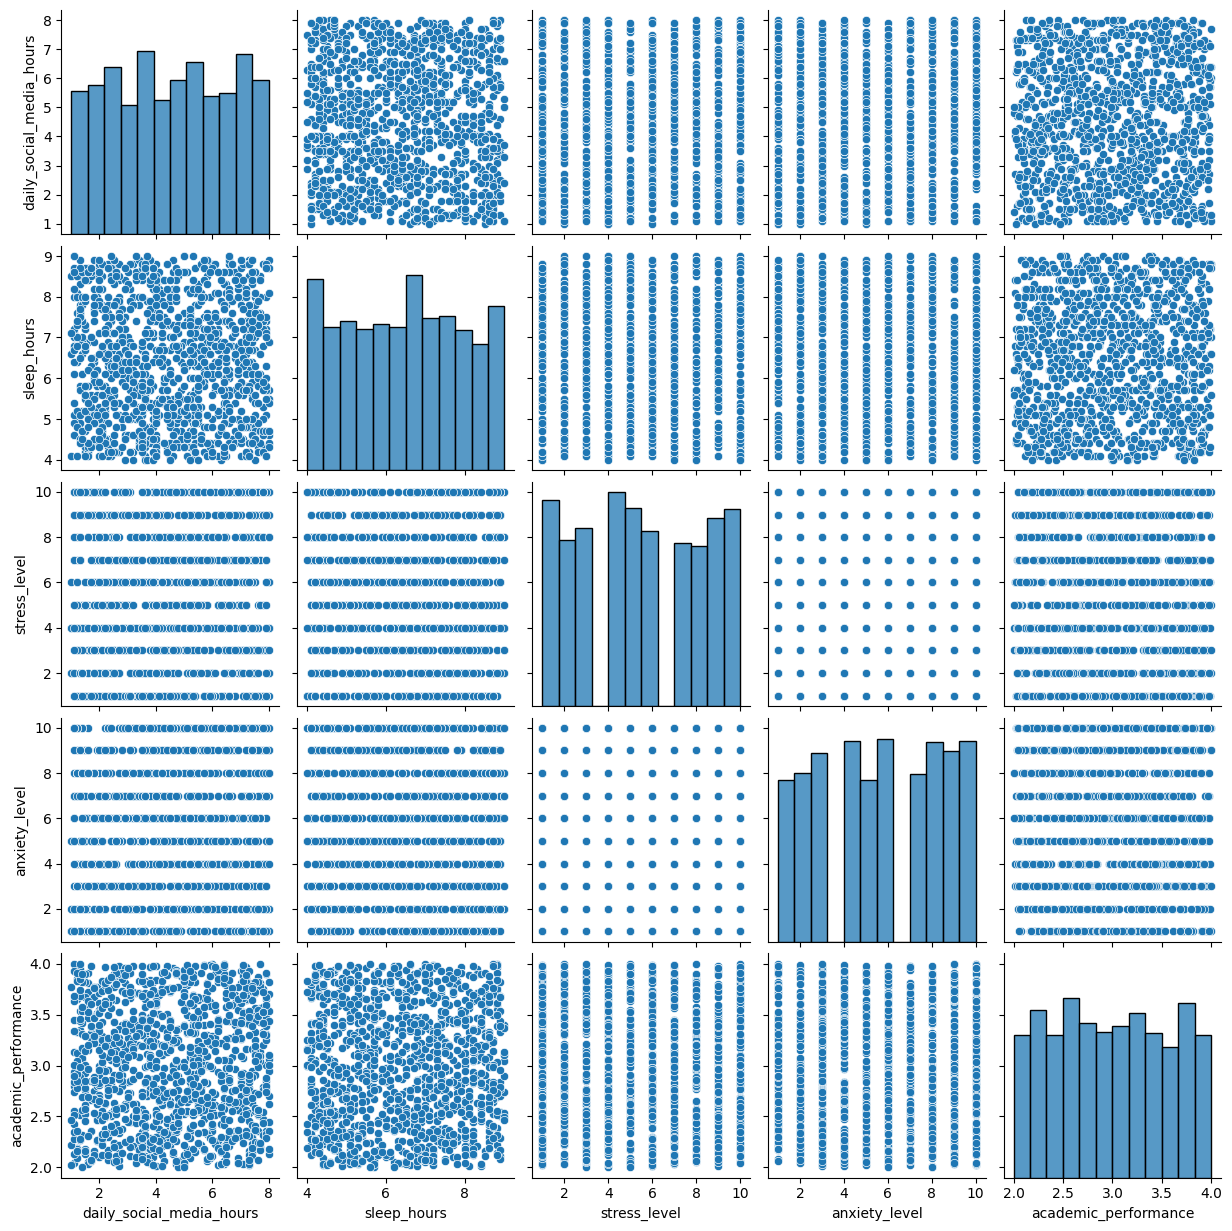

In [ ]:
sns.pairplot(
    df,
    vars=[
        "daily_social_media_hours",
        "sleep_hours",
        "stress_level",
        "anxiety_level",
        "academic_performance"
    ]
)
plt.show()

<Axes: >

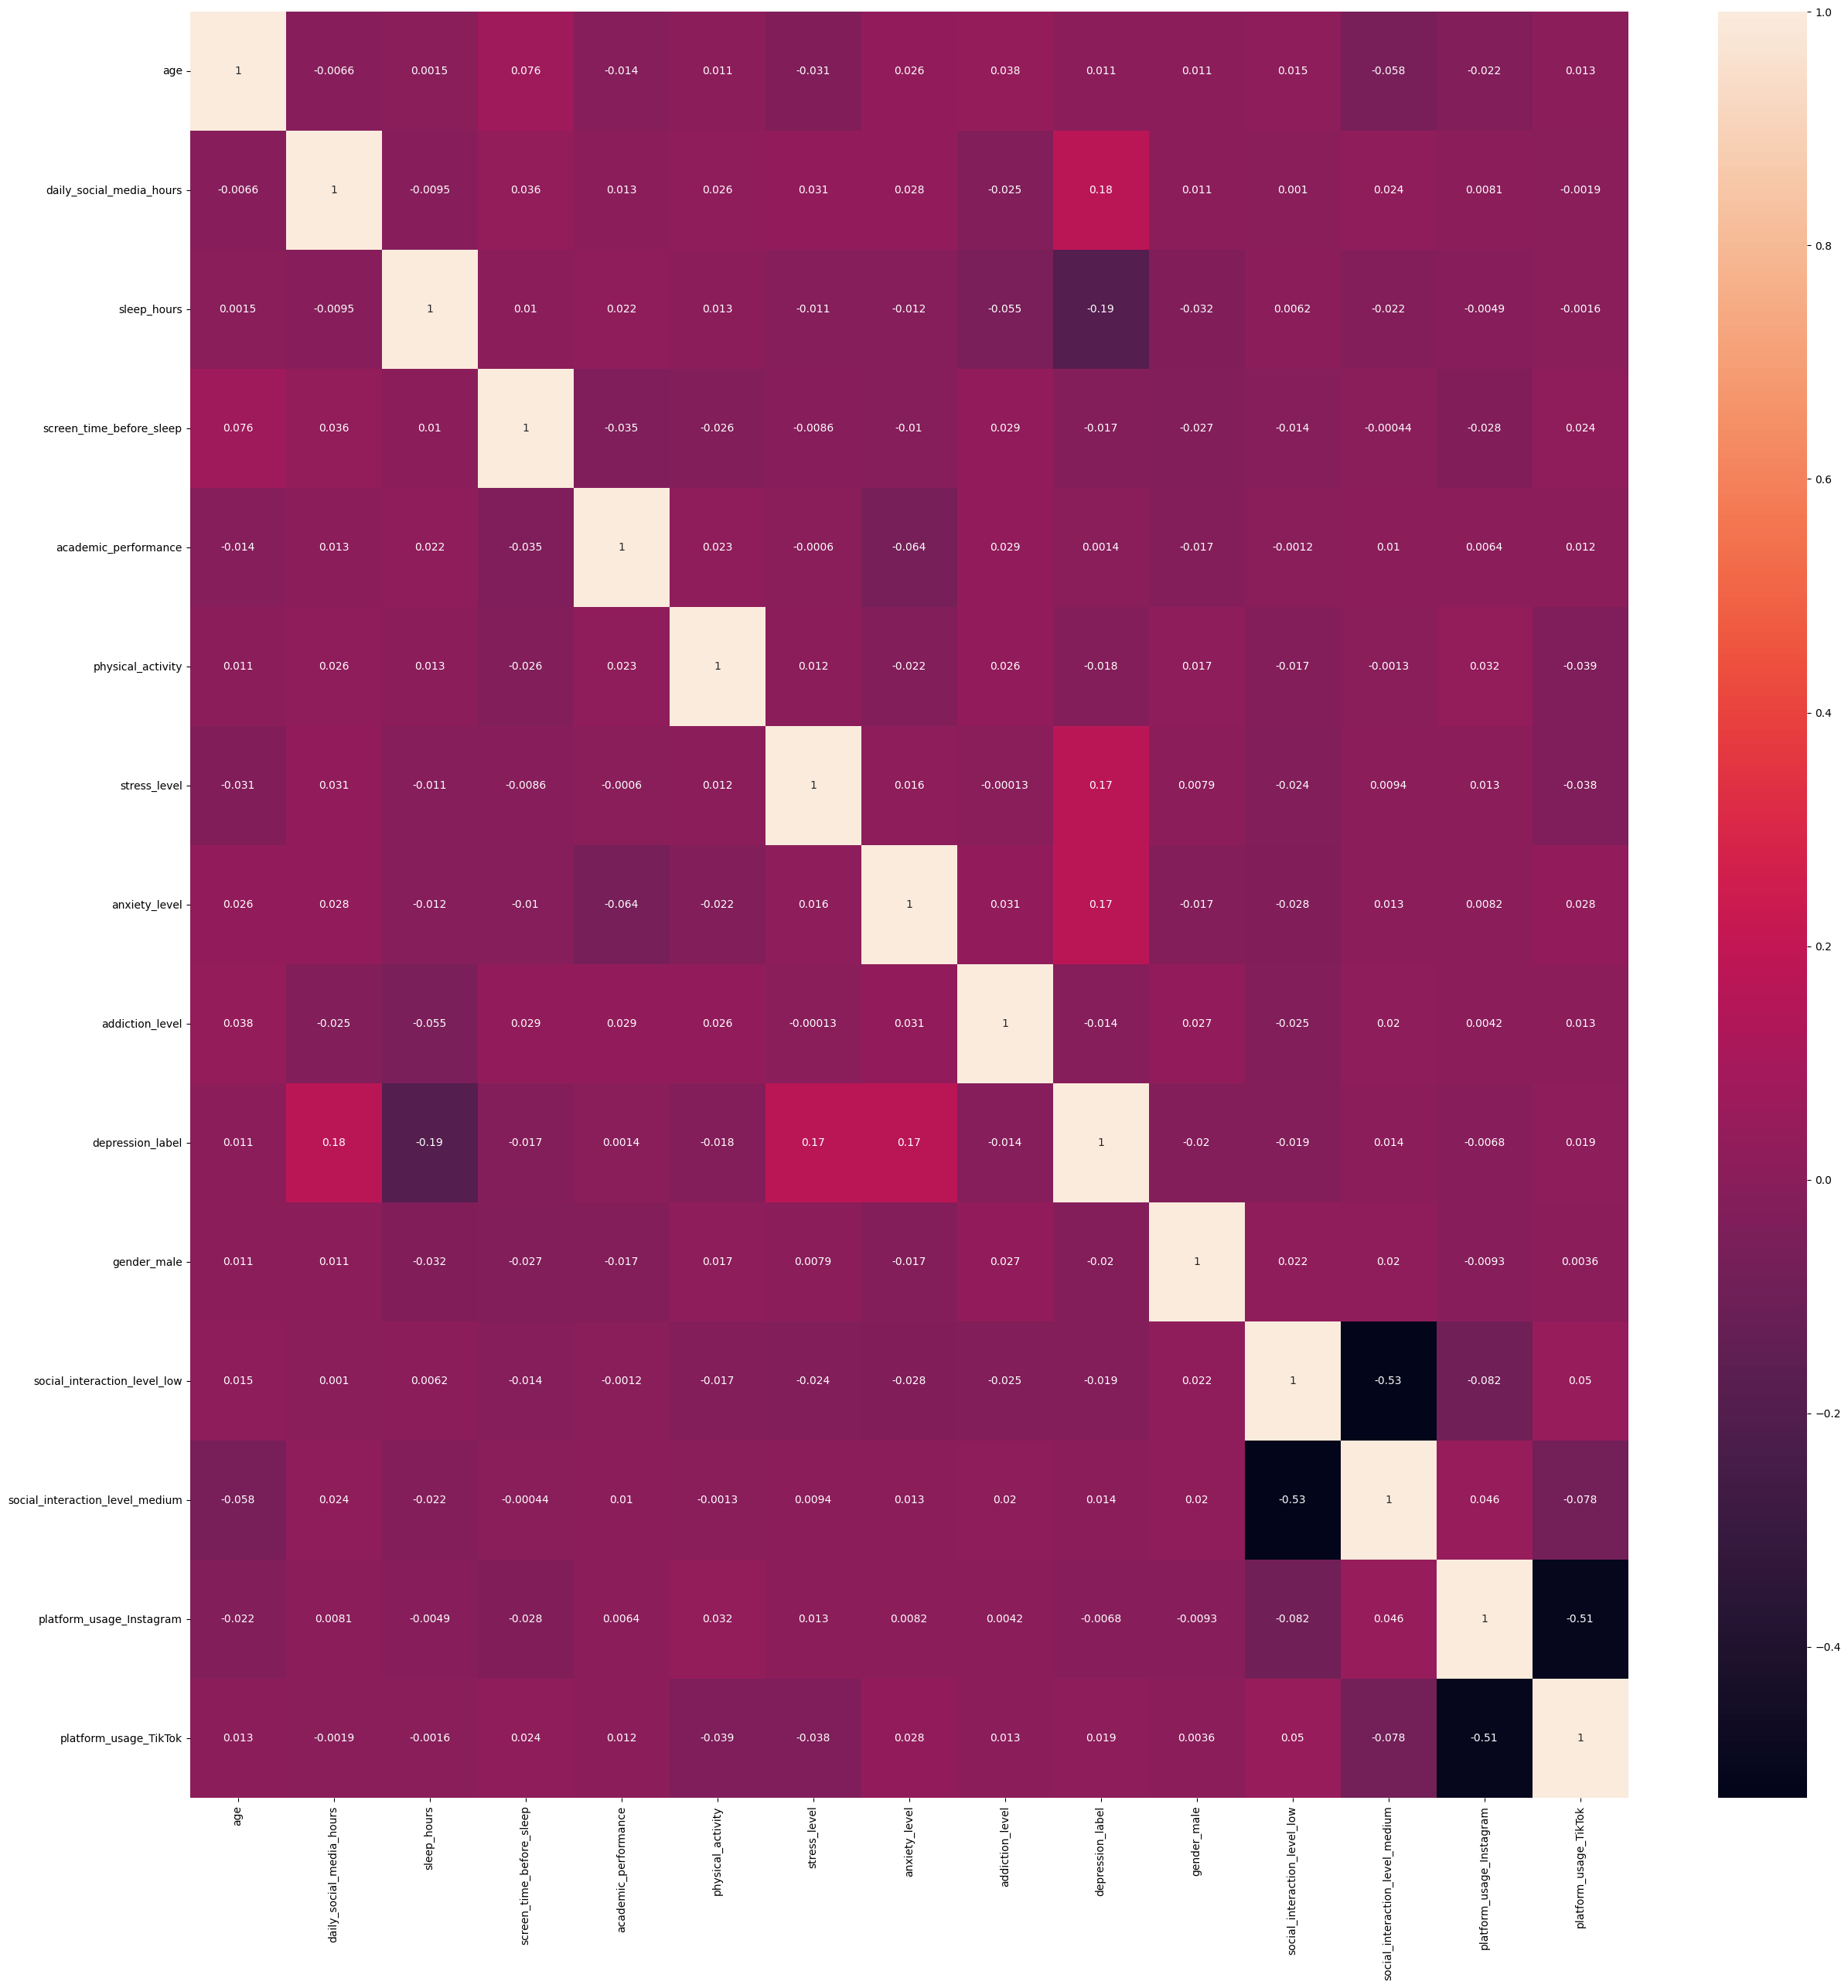

In [ ]:
plt.figure(figsize=(30,30))
corr = df.corr(numeric_only=True)

sns.heatmap(corr, annot=True)

# **Keras (ANN)**

In [ ]:
pip install tensorflow
pip install Keras

In [ ]:
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
(X_train,Y_train),(X_test,Y_test) = mnist.load_data()

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
X_train = X_train.reshape(60000,784)
X_test = X_test.reshape(10000,784)
X_train = X_train.astype('float32')
X_test = X_test.astype('float32')
X_train /= 255
X_test /= 255
classes = 10
Y_train = to_categorical(Y_train, classes)
Y_test = to_categorical(Y_test,classes)
print(X_train.shape)
Y_train.shape
X_test.shape

(60000, 784)


(10000, 784)

In [ ]:
input_size = 784
batch_size = 20
hidden_1 = 300
hidden_2 = 200
classes = 10
epochs = 10

In [ ]:
model = Sequential()
model.add(Dense(20, input_dim = input_size, activation ='relu'))
model.add(Dense(20, activation ='relu'))
model.add(Dense(classes, activation ='softmax'))
model.compile(loss = 'categorical_crossentropy',  metrics = ['accuracy'], optimizer = 'sgd',)
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 20)             │        15,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 20)             │           420 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           210 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,330 (63.79 KB)

 Trainable params: 16,330 (63.79 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from time import time
tic = time()
model.fit(X_train,Y_train,batch_size=batch_size,epochs=epochs,verbose = 1)
toc = time()
print("Model training took {} secs".format(toc-tic))

Epoch 1/10
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.9681 - loss: 0.1070
Epoch 2/10
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9685 - loss: 0.1040
Epoch 3/10
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.9691 - loss: 0.1007
Epoch 4/10
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9705 - loss: 0.0986
Epoch 5/10
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9711 - loss: 0.0962
Epoch 6/10
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.9716 - loss: 0.0940
Epoch 7/10
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9716 - loss: 0.0921
Epoch 8/10
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.9729 - loss: 0.0896
Epoch 9/10
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - accuracy: 0.9738 - loss: 0.0876
Epoch 10/10
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.9739 - loss: 0.0860
Model training took 59.54154014587402 secs


In [ ]:
from sklearn.metrics import accuracy_score
import numpy as np
y_pred = model.predict(X_test,verbose = 0)
Y_pred = np.where(y_pred>0.5,1,0)
score = accuracy_score(Y_pred,Y_test)
print(score)

0.9612


# **CNN**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import keras
import tensorflow as tf
from tensorflow.python.client import device_lib
print(device_lib.list_local_devices())

[name: "/device:CPU:0"
device_type: "CPU"
memory_limit: 268435456
locality {
}
incarnation: 5539540288811878819
xla_global_id: -1
, name: "/device:GPU:0"
device_type: "GPU"
memory_limit: 14426112000
locality {
  bus_id: 1
  links {
  }
}
incarnation: 6706788854636974549
physical_device_desc: "device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5"
xla_global_id: 416903419
]


In [ ]:
from keras.datasets import mnist
(X_train,Y_train),(X_test,Y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
X_train = X_train.reshape(X_train.shape[0],28,28,1)
X_test = X_test.reshape(X_test.shape[0],28,28,1)
X_train = X_train.astype('float32')
X_test = X_test.astype('float32')
X_train /= 255
X_test /= 255

In [ ]:
from keras.utils import to_categorical

Y_train = to_categorical(Y_train,num_classes = 10)
Y_test = to_categorical(Y_test,num_classes = 10)

In [ ]:
from keras.models import Sequential
from keras.layers import Dense,Flatten, Conv2D,MaxPooling2D

img_rows, img_cols, channels = 28,28,1
filters = [6, 32,82,120]
classes = 10

In [ ]:
model = Sequential()
model.add(Conv2D(filters[0],(3,3),padding = 'same',activation='relu',input_shape=(img_rows,img_cols,channels)))
model.add(MaxPooling2D(pool_size = (2,2)))
model.add(Conv2D(filters[1],(2,2),padding = 'same', activation = 'relu'))
model.add(MaxPooling2D(pool_size = (2,2)))
model.add(Conv2D(filters[2],(2,2),padding = 'same', activation = 'relu'))
model.add(MaxPooling2D(pool_size = (2,2)))
model.add(Conv2D(filters[3],(2,2),padding = 'same', activation = 'relu'))
model.add(MaxPooling2D(pool_size = (2,2)))
model.add(Flatten())
model.add(Dense(64,activation = 'relu'))
model.add(Dense(classes, activation = 'softmax'))
model.compile(loss = 'categorical_crossentropy',optimizer='sgd',metrics = ['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.fit(X_train,Y_train,validation_split=0.2, batch_size = 32, epochs=10,verbose=1)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 15s 6ms/step - accuracy: 0.5992 - loss: 1.2221 - val_accuracy: 0.8398 - val_loss: 0.4593
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9165 - loss: 0.2605 - val_accuracy: 0.9273 - val_loss: 0.2290
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9505 - loss: 0.1540 - val_accuracy: 0.9643 - val_loss: 0.1171
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9650 - loss: 0.1126 - val_accuracy: 0.9700 - val_loss: 0.0953
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9714 - loss: 0.0905 - val_accuracy: 0.9699 - val_loss: 0.0973
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9766 - loss: 0.0752 - val_accuracy: 0.9734 - val_loss: 0.0868
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9793 - loss: 0.0666 - val_accuracy: 0.9772 - val_loss: 0.0741
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9821 - loss: 0.0577 

In [ ]:
from sklearn.metrics import accuracy_score
import numpy as np
y_pred = model.predict(X_test,verbose = 0)
Y_pred = np.argmax(y_pred, axis=1)
Y_true = np.argmax(Y_test, axis=1)

score = accuracy_score(Y_true, Y_pred)
print(score)

0.9805


# **Autoencoders**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import keras
import tensorflow as tf
from tensorflow.keras.datasets import mnist

In [ ]:
(x_train, _),(x_test,_) = mnist.load_data()

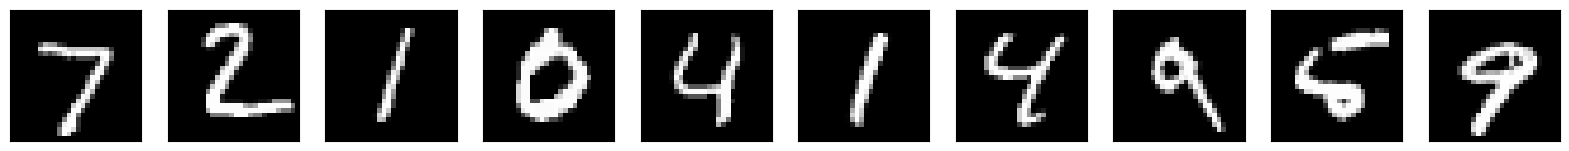

In [ ]:
n = 10
plt.figure(figsize=(20,4))
for i in range(n):
  ax = plt.subplot(1,n,i+1)
  plt.imshow(x_test[i].reshape(28,28))
  plt.gray()
  ax.get_xaxis().set_visible(False)
  ax.get_yaxis().set_visible(False)
plt.show()
plt.close()

In [ ]:
x_train = x_train.astype('float32')/255
x_test = x_test.astype('float32')/255
x_train = x_train.reshape((len(x_train),28*28*1))
x_test = x_test.reshape((len(x_test),28*28*1))
print(x_train.shape,x_test.shape)

(60000, 784) (10000, 784)


# **Convolutional Autoencoders**

In [ ]:
from tensorflow.keras.layers import Input,Conv2D, MaxPooling2D,UpSampling2D,Flatten, Reshape
from tensorflow.keras.models import Model

In [ ]:
input_layer_cnv = Input(shape = (28,28,1))
ae_cnv_en = Conv2D(32,(3,3),activation = 'relu',padding = 'same',kernel_initializer = 'he_normal')(input_layer_cnv)
ae_cnv_en = MaxPooling2D((2,2),padding = 'same')(ae_cnv_en)

ae_cnv_en = Conv2D(32,(3,3),activation = 'relu',padding = 'same')(ae_cnv_en)
ae_cnv_en = MaxPooling2D((2,2),padding = 'same')(ae_cnv_en)

ae_cnv_en = Conv2D(4,(3,3),activation = 'relu',padding = 'same')(ae_cnv_en)
ae_cnv_en = MaxPooling2D((2,2),padding = 'same')(ae_cnv_en)

ae_cnv_en = Flatten(name='bot')(ae_cnv_en)

ae_cnv_de = Reshape((4,4,4), name='botnext0')(ae_cnv_en)

ae_cnv_de = Conv2D(4,(3,3), activation='relu',padding = 'same',name='botnext1')(ae_cnv_de)
ae_cnv_de = UpSampling2D((2,2), name = 'botnext2')(ae_cnv_de)

ae_cnv_de = Conv2D(32,(3,3), activation='relu',padding = 'same',name='botnext3')(ae_cnv_de)
ae_cnv_de = UpSampling2D((2,2), name = 'botnext4')(ae_cnv_de)

ae_cnv_de = Conv2D(32,(3,3), activation='relu',padding = 'valid',name='botnext5')(ae_cnv_de)
ae_cnv_de = UpSampling2D((2,2), name = 'botnext6')(ae_cnv_de)

ae_cnv_de = Conv2D(1,(3,3), activation='sigmoid',padding = 'same',name='botnext7')(ae_cnv_de)
Ae_Conv = Model(inputs=input_layer_cnv,outputs=ae_cnv_de)

Ae_Conv.compile(optimizer=tf.keras.optimizers.SGD(
    learning_rate=0.09,
    clipvalue=2.5
),loss = 'binary_crossentropy',metrics=['accuracy'])
Ae_Conv.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 14, 14, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 7, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 7, 7, 4)        │         1,156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 4, 4, 4)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bot (Flatten)                   │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ botnext0 (Reshape)              │ (None, 4, 4, 4)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ botnext1 (Conv2D)               │ (None, 4, 4, 4)        │           148 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ botnext2 (UpSampling2D)         │ (None, 8, 8, 4)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ botnext3 (Conv2D)               │ (None, 8, 8, 32)       │         1,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ botnext4 (UpSampling2D)         │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ botnext5 (Conv2D)               │ (None, 14, 14, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ botnext6 (UpSampling2D)         │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ botnext7 (Conv2D)               │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,593 (84.35 KB)

 Trainable params: 21,593 (84.35 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
x_train = x_train.reshape(x_train.shape[0],28,28,1)
x_test = x_test.reshape(x_test.shape[0],28,28,1)
print(x_train.shape,x_test.shape)

(60000, 28, 28, 1) (10000, 28, 28, 1)


In [ ]:
from time import time
tic = time()
Ae_Conv.fit(x_train,x_train,epochs=100,batch_size=2048,verbose=2, shuffle= False, validation_split=0.1)
toc = time()
print("Total training time of Autoencoder is: ",toc-tic," seconds")

Epoch 1/100
27/27 - 8s - 300ms/step - accuracy: 0.7898 - loss: 0.4885 - val_accuracy: 0.8088 - val_loss: 0.3346
Epoch 2/100
27/27 - 2s - 66ms/step - accuracy: 0.8057 - loss: 0.2806 - val_accuracy: 0.8085 - val_loss: 0.2549
Epoch 3/100
27/27 - 2s - 65ms/step - accuracy: 0.7994 - loss: 0.2495 - val_accuracy: 0.7967 - val_loss: 0.2353
Epoch 4/100
27/27 - 2s - 66ms/step - accuracy: 0.7963 - loss: 0.2386 - val_accuracy: 0.8074 - val_loss: 0.2322
Epoch 5/100
27/27 - 2s - 86ms/step - accuracy: 0.7956 - loss: 0.2289 - val_accuracy: 0.7935 - val_loss: 0.2190
Epoch 6/100
27/27 - 2s - 84ms/step - accuracy: 0.7933 - loss: 0.2227 - val_accuracy: 0.8056 - val_loss: 0.2185
Epoch 7/100
27/27 - 2s - 80ms/step - accuracy: 0.7935 - loss: 0.2159 - val_accuracy: 0.7940 - val_loss: 0.2058
Epoch 8/100
27/27 - 2s - 68ms/step - accuracy: 0.7917 - loss: 0.2110 - val_accuracy: 0.8044 - val_loss: 0.2075
Epoch 9/100
27/27 - 2s - 65ms/step - accuracy: 0.7926 - loss: 0.2054 - val_accuracy: 0.7932 - val_loss: 0.1973


In [ ]:
pred = Ae_Conv.predict(x_test)


313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


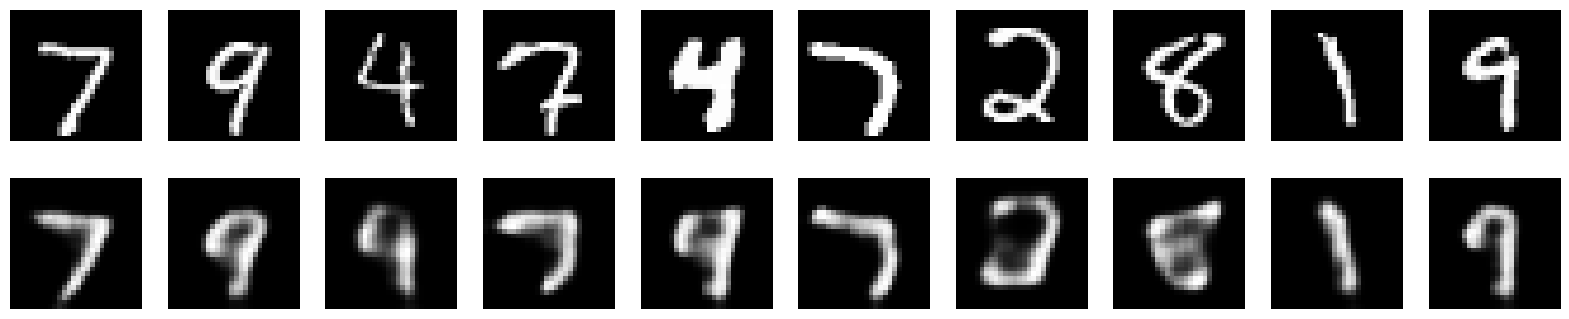

In [ ]:
pred = Ae_Conv.predict(x_test)

n = 10
k = 12

plt.figure(figsize=(20,4))

for i in range(n):

    # Original
    plt.subplot(2, n, i+1)
    plt.imshow(x_test[i*k].squeeze(), cmap='gray')
    plt.axis('off')

    # Reconstruction
    plt.subplot(2, n, i+1+n)
    plt.imshow(pred[i*k].squeeze(), cmap='gray')
    plt.axis('off')

plt.show()

# **Encoder Part:**

In [ ]:
Encoder = Model(
    inputs=input_layer_cnv,
    outputs=ae_cnv_en
)
predic = Encoder.predict(x_test)
pred.shape

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


(10000, 28, 28, 1)

# **Decoder Part:**

In [ ]:
decoder_input = Input(shape=(64,))

x = decoder_input
for layer_name in ['botnext0','botnext1','botnext2','botnext3',
                   'botnext4','botnext5','botnext6','botnext7']:
    x = Ae_Conv.get_layer(layer_name)(x)

Decoder = Model(decoder_input, x)
prediction = Decoder.predict(predic)
prediction.shape

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


(10000, 28, 28, 1)

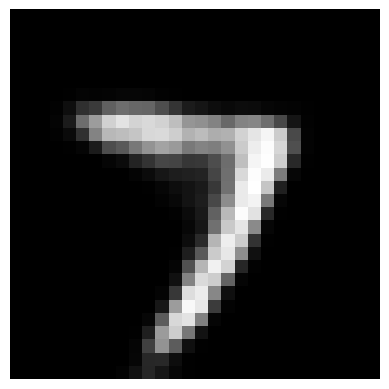

In [ ]:
plt.imshow(prediction[0].squeeze(), cmap="gray")
plt.axis("off")
plt.show()

# **Denoising Autoencoders**

In [ ]:
noise_factor = 0.5
x_train_noisy = x_train+noise_factor*np.random.normal(loc=0.0,scale=1.0,size = x_train.shape)
x_test_noisy = x_test+noise_factor*np.random.normal(loc=0.0,scale=1.0,size = x_test.shape)
x_train_noisy = np.clip(x_train_noisy, 0., 1.)
x_test_noisy = np.clip(x_test_noisy, 0., 1.)

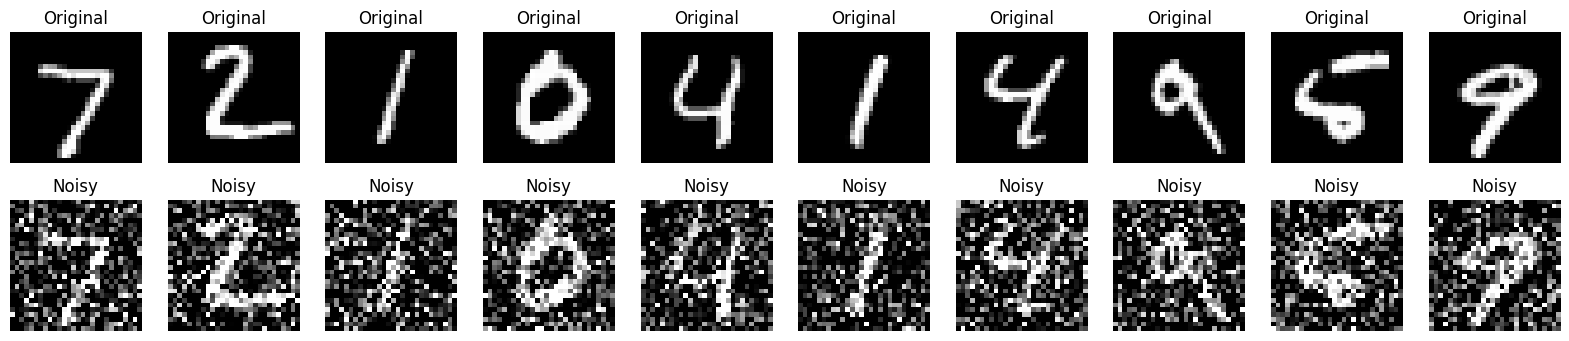

In [ ]:
import matplotlib.pyplot as plt

n = 10

plt.figure(figsize=(20,4))

for i in range(n):

    # Original image
    plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i].squeeze(), cmap='gray')
    plt.title("Original")
    plt.axis('off')

    # Noisy image
    plt.subplot(2, n, i + 1 + n)
    plt.imshow(x_test_noisy[i].squeeze(), cmap='gray')
    plt.title("Noisy")
    plt.axis('off')

plt.show()

In [ ]:
from time import time
tic = time()
Ae_Conv.fit(x_train_noisy,x_train,epochs=100,batch_size=2048,verbose=1, shuffle= False, validation_split=0.1)
toc = time()
print("Total training time of Autoencoder is: ",toc-tic," seconds")

Epoch 1/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 70ms/step - accuracy: 0.7960 - loss: 0.2246 - val_accuracy: 0.8044 - val_loss: 0.2043
Epoch 2/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 67ms/step - accuracy: 0.7973 - loss: 0.1977 - val_accuracy: 0.8055 - val_loss: 0.2026
Epoch 3/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 70ms/step - accuracy: 0.7980 - loss: 0.1911 - val_accuracy: 0.8055 - val_loss: 0.1949
Epoch 4/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 72ms/step - accuracy: 0.7984 - loss: 0.1873 - val_accuracy: 0.8053 - val_loss: 0.1895
Epoch 5/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 89ms/step - accuracy: 0.7987 - loss: 0.1845 - val_accuracy: 0.8052 - val_loss: 0.1862
Epoch 6/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 83ms/step - accuracy: 0.7990 - loss: 0.1823 - val_accuracy: 0.8051 - val_loss: 0.1837
Epoch 7/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 88ms/step - accuracy: 0.7992 - loss: 0.1806 - val_accuracy: 0.8050 - val_loss: 0.1817
Epoch 8/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 68ms/step - accuracy: 0.7995 - loss: 0.1792 - val_accuracy: 0.

**Also try Separate Encoder and Decoder Parts for this model as well...!!!**

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


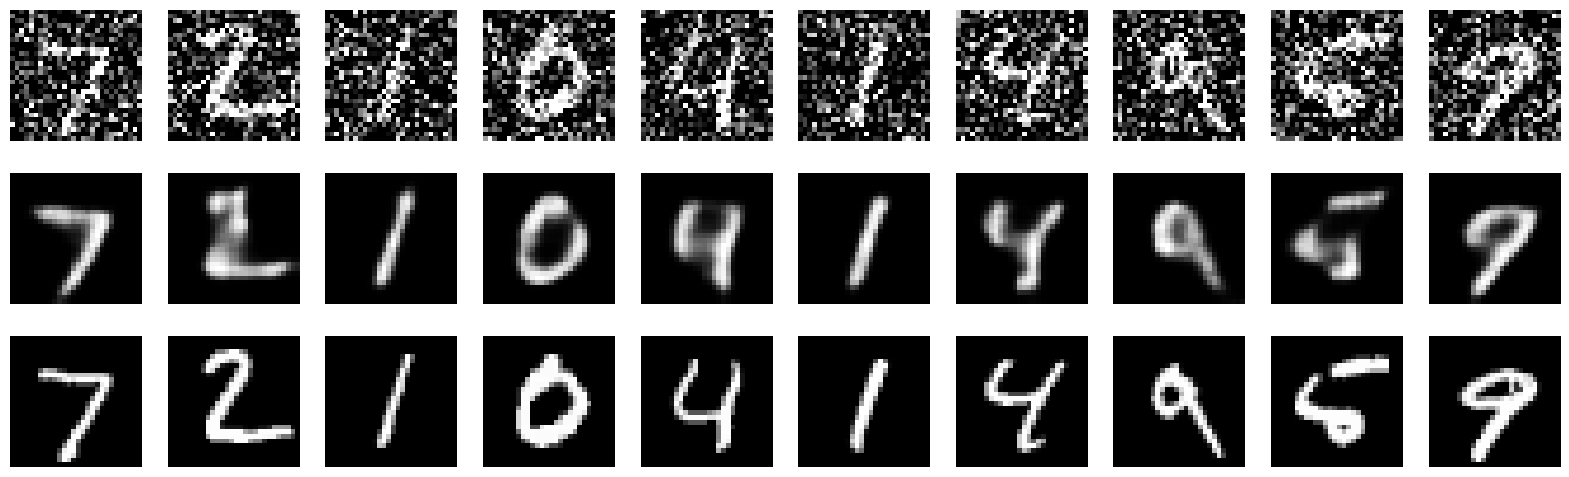

In [ ]:
decoded_images = Ae_Conv.predict(x_test_noisy)

n = 10

plt.figure(figsize=(20,6))

for i in range(n):

    # Noisy image
    plt.subplot(3, n, i+1)
    plt.imshow(x_test_noisy[i].squeeze(), cmap='gray')
    plt.axis('off')

    # Denoised output
    plt.subplot(3, n, i+1+n)
    plt.imshow(pred[i].squeeze(), cmap='gray')
    plt.axis('off')

    # Original image
    plt.subplot(3, n, i+1+2*n)
    plt.imshow(x_test[i].squeeze(), cmap='gray')
    plt.axis('off')

plt.show()

# **PyTorch**

***Regression Model:***

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
import pandas as pd
print("Success!")

Success!


In [ ]:
data = fetch_california_housing()
x= data.data
y=data.target
X_df = pd.DataFrame(x,columns=data.feature_names)
print(X_df.head())
Y_df = pd.DataFrame(y,columns=['target'])
Y_df.head()

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  
0    -122.23  
1    -122.22  
2    -122.24  
3    -122.25  
4    -122.25  


,target
0,4.526
1,3.585
2,3.521
3,3.413
4,3.422


In [ ]:
X_train,X_test,Y_train,Y_test = train_test_split(x,y,test_size=0.2,random_state=101)

In [ ]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)
X_train

array([[ 0.4507375 ,  1.54231204,  0.66346454, ..., -0.0473437 ,
        -0.6763631 ,  0.72026503],
       [-0.84694133,  1.14432091, -0.04881265, ..., -0.08820916,
         1.91635176, -1.1298396 ],
       [ 0.15674859, -0.68643828,  0.5456924 , ..., -0.06404969,
         1.47722527, -0.78575006],
       ...,
       [ 1.1980295 , -1.80081344,  0.75179779, ..., -0.02429384,
         0.77649153, -1.08994516],
       [-0.3103484 ,  0.58713333, -0.63680233, ..., -0.04477886,
         0.79984932, -1.18469445],
       [-0.63118801, -0.44764361, -0.11507995, ..., -0.01937388,
         0.5662714 , -0.97524865]])

In [ ]:
X_train = torch.FloatTensor(X_train)
Y_train = torch.FloatTensor(Y_train)
X_test=torch.FloatTensor(X_test)
Y_test=torch.FloatTensor(Y_test)
X_train

tensor([[ 0.4507,  1.5423,  0.6635,  ..., -0.0473, -0.6764,  0.7203],
        [-0.8469,  1.1443, -0.0488,  ..., -0.0882,  1.9164, -1.1298],
        [ 0.1567, -0.6864,  0.5457,  ..., -0.0640,  1.4772, -0.7858],
        ...,
        [ 1.1980, -1.8008,  0.7518,  ..., -0.0243,  0.7765, -1.0899],
        [-0.3103,  0.5871, -0.6368,  ..., -0.0448,  0.7998, -1.1847],
        [-0.6312, -0.4476, -0.1151,  ..., -0.0194,  0.5663, -0.9752]])

In [ ]:
class RegressionModel(nn.Module):
  def __init__(self,input_size):
    super(RegressionModel,self).__init__()
    self.fc1 = nn.Linear(input_size,64)
    self.relu = nn.ReLU()
    self.fc2 = nn.Linear(64,128)
    self.relu = nn.ReLU()
    self.fc3 = nn.Linear(128,15)
    self.relu = nn.ReLU()
    self.fc4 = nn.Linear(15,1)
  def forward(self,x):
    x=self.fc1(x)
    x=self.relu(x)
    x=self.fc2(x)
    x=self.relu(x)
    x=self.fc3(x)
    x=self.relu(x)
    x=self.fc4(x)
    return x

In [ ]:
input_size = X_train.shape[1]
print(input_size)
model = RegressionModel(input_size)
print(model)

8
RegressionModel(
  (fc1): Linear(in_features=8, out_features=64, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=64, out_features=128, bias=True)
  (fc3): Linear(in_features=128, out_features=15, bias=True)
  (fc4): Linear(in_features=15, out_features=1, bias=True)
)


In [ ]:
loss_fun = nn.MSELoss()
optimizer = optim.SGD(model.parameters(),lr=0.001)

In [ ]:
num_epochs = 500
for epoch in range(num_epochs):
  outputs = model(X_train)
  loss = loss_fun(outputs,Y_train.view(-1,1))
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()
  if(epoch+1)%10 == 0:
    print(f'Epoch: {epoch+1}/{num_epochs} - Loss: {loss.item():.4f}')


Epoch: 10/500 - Loss: 6.2828
Epoch: 20/500 - Loss: 5.9929
Epoch: 30/500 - Loss: 5.7095
Epoch: 40/500 - Loss: 5.4317
Epoch: 50/500 - Loss: 5.1581
Epoch: 60/500 - Loss: 4.8879
Epoch: 70/500 - Loss: 4.6206
Epoch: 80/500 - Loss: 4.3562
Epoch: 90/500 - Loss: 4.0951
Epoch: 100/500 - Loss: 3.8379
Epoch: 110/500 - Loss: 3.5856
Epoch: 120/500 - Loss: 3.3396
Epoch: 130/500 - Loss: 3.1019
Epoch: 140/500 - Loss: 2.8746
Epoch: 150/500 - Loss: 2.6599
Epoch: 160/500 - Loss: 2.4600
Epoch: 170/500 - Loss: 2.2769
Epoch: 180/500 - Loss: 2.1118
Epoch: 190/500 - Loss: 1.9655
Epoch: 200/500 - Loss: 1.8381
Epoch: 210/500 - Loss: 1.7288
Epoch: 220/500 - Loss: 1.6361
Epoch: 230/500 - Loss: 1.5584
Epoch: 240/500 - Loss: 1.4935
Epoch: 250/500 - Loss: 1.4394
Epoch: 260/500 - Loss: 1.3940
Epoch: 270/500 - Loss: 1.3556
Epoch: 280/500 - Loss: 1.3226
Epoch: 290/500 - Loss: 1.2939
Epoch: 300/500 - Loss: 1.2683
Epoch: 310/500 - Loss: 1.2452
Epoch: 320/500 - Loss: 1.2240
Epoch: 330/500 - Loss: 1.2042
Epoch: 340/500 - Lo

In [ ]:
torch.save(model.state_dict(),'california_housing_model.pth')

In [ ]:
loaded_model = RegressionModel(input_size)
loaded_model.load_state_dict(torch.load('california_housing_model.pth'))

<All keys matched successfully>

In [ ]:
with torch.no_grad():
  y_pred = loaded_model(X_test)
  mse = mean_squared_error(Y_test.numpy(),y_pred.numpy())
  print(f'mean_squared_error for loaded model is: {mse:.4f}')

mean_squared_error for loaded model is: 0.9814


***Classification Model:***

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import numpy as np
from torchvision import datasets,transforms
from torch.utils.data.sampler import SubsetRandomSampler
import matplotlib.pyplot as plt
%matplotlib inline

In [ ]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(device)

cpu


In [ ]:
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,),(0.5,))])
trainset = datasets.FashionMNIST('~/.pytorch/F_MNIST_Data',download=True,train=True,transform=transform)
testset=   datasets.FashionMNIST('~/.pytorch/F_MNIST_Data',download=True,train=False,transform=transform)
indices = list(range(len(trainset)))
np.random.shuffle(indices)
split = int(np.floor(0.2*len(trainset)))
train_sample=SubsetRandomSampler(indices[:split])
valid_sample=SubsetRandomSampler(indices[split:])

100%|██████████| 26.4M/26.4M [00:01<00:00, 14.3MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 210kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.93MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 13.5MB/s]


In [ ]:
train_loader = torch.utils.data.DataLoader(trainset,sampler=train_sample, batch_size=64)
valid_loader= torch.utils.data.DataLoader(trainset,sampler=valid_sample, batch_size=64)
test_loader = torch.utils.data.DataLoader(testset, batch_size=64,shuffle=True)

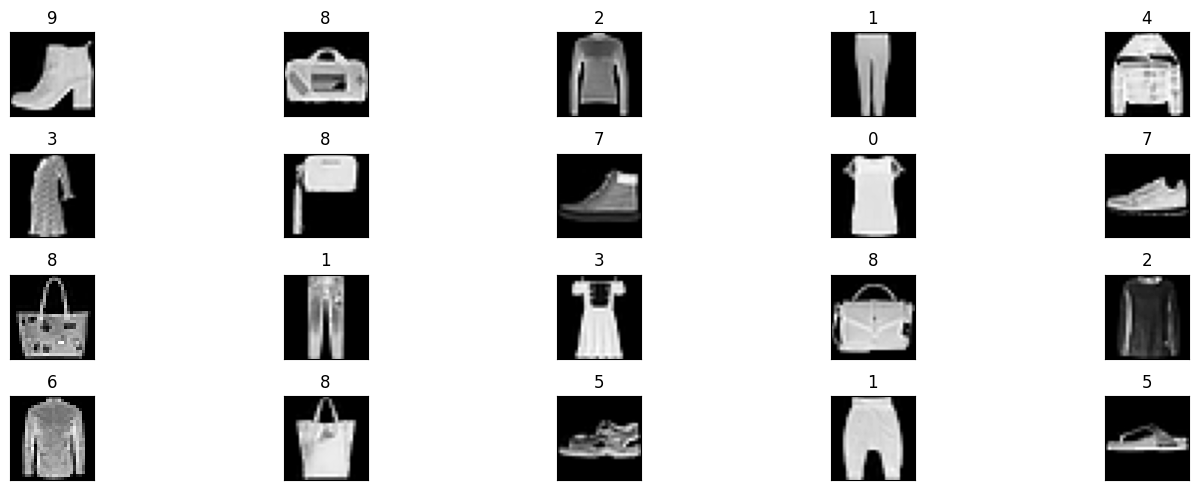

In [ ]:
detaitor = iter(train_loader)
print(detaitor)
images,labels = next(detaitor)
fig = plt.figure(figsize=(15,5))
for index in np.arange(20):
  ax = fig.add_subplot(4,int(20/4),index+1,xticks=[],yticks=[])
  ax.imshow(np.squeeze(images[index]),cmap='gray')
  ax.set_title(labels[index].item())
fig.tight_layout()

In [ ]:
class Classifier(nn.Module):
  def __init__(self):
    super().__init__()
    self.fc1=nn.Linear(784,120)
    self.fc2=nn.Linear(120,120)
    self.fc3=nn.Linear(120,10)
    self.dropout=nn.Dropout(0.2)

  def forward(self,x):
    x=x.view(x.shape[0],-1)
    x=self.dropout(F.relu(self.fc1(x)))
    x=self.dropout(F.relu(self.fc2(x)))
    x=F.log_softmax(self.fc3(x),dim=1)
    return x

In [ ]:
model = Classifier()
criterion = nn.NLLLoss()
optimizer = optim.SGD(model.parameters(),lr=0.01)
valid_loss_min = np.inf
epochs = 40
steps=0
model.train()
train_losses, valid_losses = [],[]

for e in range(epochs):
  running_loss=0
  valid_loss=0

  for images,labels in train_loader:
    optimizer.zero_grad()
    log_ps = model(images)
    loss = criterion(log_ps,labels)
    loss.backward()
    optimizer.step()
    running_loss += loss.item()*images.size(0)

  for images,labels in valid_loader:
    log_ps = model(images)
    loss = criterion(log_ps,labels)
    valid_loss += loss.item()*images.size(0)

  running_loss = running_loss/len(train_loader.sampler)
  valid_loss = valid_loss/len(valid_loader.sampler)

  train_losses.append(running_loss)
  valid_losses.append(valid_loss)

  if valid_loss <= valid_loss_min:
    torch.save(model.state_dict(),'model.pt')
    valid_loss_min = valid_loss


In [ ]:
print(train_losses,"\n",valid_losses)   #is model overfit?
# Practice class-wise accuracy
# practice testing
# practice plotting + plotting images with labels

[1.9159918193817138, 1.1637520675659179, 0.9018397464752197, 0.7912787823677063, 0.7290118316014608, 0.6886637167930603, 0.6502606921195984, 0.6313597888946533, 0.6037964005470275, 0.581745809396108, 0.5671020285288493, 0.555009029229482, 0.5378669989903768, 0.5297982358932495, 0.5167606282234192, 0.5132010620435079, 0.504547291914622, 0.4938295230865479, 0.4881136241753896, 0.47629161659876507, 0.4720454867680868, 0.46480569593111676, 0.45732307608922323, 0.45209345185756683, 0.44764741230010985, 0.4417425283590953, 0.4348533132870992, 0.43661780953407286, 0.42337427401542665, 0.4227697375615438, 0.4173741448322932, 0.4111277941862742, 0.409148694674174, 0.4047363015810649, 0.39873393495877585, 0.3969071593284607, 0.3946279446283976, 0.3900794758796692, 0.3877313407262166, 0.38440501228968305] 
 [1.4431695143381755, 1.0063667656580606, 0.85323575146993, 0.7733120599985123, 0.7204827444156011, 0.6900303302605947, 0.6601750702063243, 0.6371017070611318, 0.6162982110579809, 0.60016673254

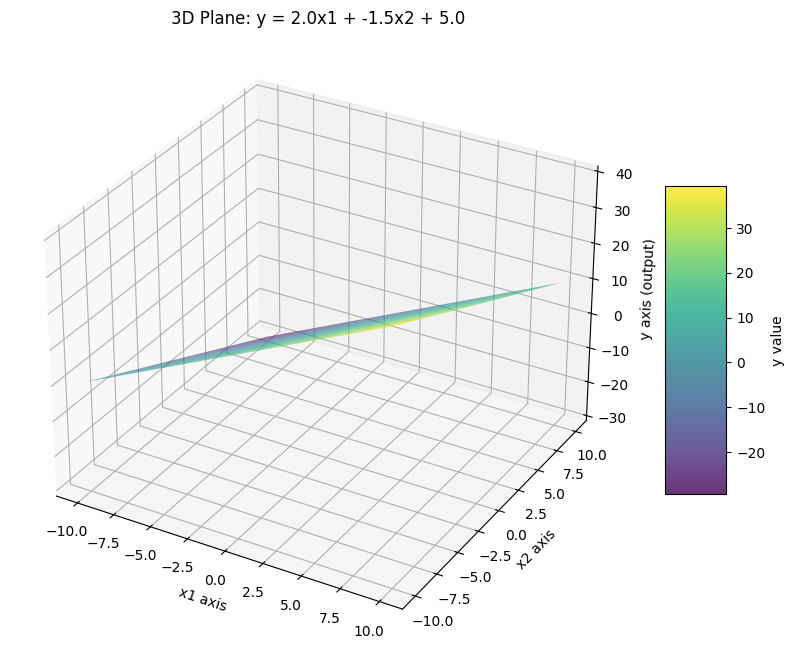

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Define your parameters (weights and bias)
w1 = 2.0
w2 = -1.5
b = 5.0

# 2. Generate data for x1 and x2
# linspace creates an array of 50 evenly spaced numbers between -10 and 10
x1_range = np.linspace(-10, 10, 50)
x2_range = np.linspace(-10, 10, 50)

# meshgrid creates a 2D coordinate matrix from the 1D arrays
X1, X2 = np.meshgrid(x1_range, x2_range)

# 3. Calculate y for every combination of x1 and x2
Y = (w1 * X1) + (w2 * X2) + b

# 4. Create the 3D plot
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot the surface
surface = ax.plot_surface(X1, X2, Y, cmap='viridis', edgecolor='none', alpha=0.8)

# Add labels and title
ax.set_xlabel('x1 axis')
ax.set_ylabel('x2 axis')
ax.set_zlabel('y axis (output)')
ax.set_title(f'3D Plane: y = {w1}x1 + {w2}x2 + {b}')

# Add a color bar to map colors to y-values
fig.colorbar(surface, shrink=0.5, aspect=5, label='y value')

plt.show()